In [2]:
"""
ESS Battery Health - Day 1: EDA
===============================
논문: Severson et al., "Data-driven prediction of battery cycle life
      before capacity degradation" (Nature Energy, 2019)

목표: 3개 Batch에 대한 탐색적 데이터 분석 및 Batch 간 특징 비교

| Batch   | 역할             |
|---------|-----------------|
| Batch 1 | Train           |
| Batch 2 | Primary Test    |
| Batch 3 | Secondary Test  |
"""

'\nESS Battery Health - Day 1: EDA\n===============================\n논문: Severson et al., "Data-driven prediction of battery cycle life\n      before capacity degradation" (Nature Energy, 2019)\n\n목표: 3개 Batch에 대한 탐색적 데이터 분석 및 Batch 간 특징 비교\n\n| Batch   | 역할             |\n|---------|-----------------|\n| Batch 1 | Train           |\n| Batch 2 | Primary Test    |\n| Batch 3 | Secondary Test  |\n'

# 0. Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import h5py
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter
import re, os, platform, warnings
warnings.filterwarnings('ignore')

# ============================================================
# 한글 폰트 설정
# ============================================================
# 우선순위:
#   1) koreanize-matplotlib 패키지 (pip install koreanize-matplotlib)
#   2) OS별 시스템 폰트 탐색
#   3) 기본 sans-serif (영문은 항상 정상 렌더링)
# ============================================================
def set_korean_font():
    # ── 방법 1: koreanize-matplotlib (NanumGothic 자동 설치) ──────────
    try:
        import koreanize_matplotlib  # noqa: F401
        plt.rcParams['axes.unicode_minus'] = False
        print('[Font] koreanize-matplotlib → NanumGothic 설정 완료')
        return
    except ImportError:
        pass

    # ── 방법 2: OS별 폰트 탐색 ────────────────────────────────────────
    system   = platform.system()
    available = {f.name for f in fm.fontManager.ttflist}

    if system == 'Darwin':     # macOS
        candidates = ['Apple SD Gothic Neo', 'AppleGothic',
                      'Noto Sans KR', 'NanumGothic']
    elif system == 'Windows':
        candidates = ['Malgun Gothic', 'NanumGothic', 'Gulim']
    else:                      # Linux
        candidates = ['NanumGothic', 'Noto Sans CJK KR',
                      'Noto Sans KR', 'Droid Sans Fallback', 'UnDotum']

    found = next((f for f in candidates if f in available), None)

    if found:
        # font.family 직접 지정 대신 sans-serif 목록에 추가 →
        # 한글 폰트가 없어도 영문은 항상 정상 렌더링됨
        plt.rcParams['font.sans-serif'] = [found] + \
            list(plt.rcParams.get('font.sans-serif', []))
        plt.rcParams['font.family'] = 'sans-serif'
        print(f'[Font] {found} 설정 완료 ({system})')
    else:
        plt.rcParams['font.family'] = 'sans-serif'
        print(f'[Font] 한글 폰트 없음 → 기본 sans-serif 사용 ({system})')
        print('       한글 폰트 설치: pip install koreanize-matplotlib')

    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

BATCH_COLORS = {'Batch 1': '#2196F3', 'Batch 2': '#FF9800', 'Batch 3': '#4CAF50'}
BATCHES      = ['Batch 1', 'Batch 2', 'Batch 3']
os.makedirs('figures', exist_ok=True)

[Font] Apple SD Gothic Neo 설정 완료 (Darwin)


# 0. 데이터 로딩

In [4]:
DATA_DIR = 'data'

def load_batch_h5py(filepath):
    f     = h5py.File(filepath, 'r')
    batch = f['batch']
    cells = []
    for i in range(batch['cycle_life'].shape[0]):
        cell   = {}
        cl_val = f[batch['cycle_life'][i, 0]][()].flatten()[0]
        if np.isnan(cl_val):
            continue
        cell['cycle_life'] = int(cl_val)

        raw = f[batch['policy_readable'][i, 0]][()].flatten()
        cell['policy'] = ''.join([chr(int(c)) for c in raw])

        summ = f[batch['summary'][i, 0]]
        cell['summary'] = {k: summ[k][()].flatten() for k in summ.keys()}
        cell['Vdlin']   = f[batch['Vdlin'][i, 0]][()].flatten()

        cyc_grp = f[batch['cycles'][i, 0]]
        n_cyc   = cyc_grp['Qdlin'].shape[0]
        cell['n_cycles'] = n_cyc

        qdlin_all = []
        for c in range(n_cyc):
            q = f[cyc_grp['Qdlin'][c, 0]][()].flatten()
            qdlin_all.append(q if len(q) == 1000 else np.full(1000, np.nan))
        cell['Qdlin'] = np.array(qdlin_all)
        cells.append(cell)
    f.close()
    return cells

print('Batch 1 로딩 중...')
batch1 = load_batch_h5py(f'{DATA_DIR}/batch1.mat')
print(f'  완료: {len(batch1)} 셀')
print('Batch 2 로딩 중...')
batch2 = load_batch_h5py(f'{DATA_DIR}/batch2.mat')
print(f'  완료: {len(batch2)} 셀')
print('Batch 3 로딩 중...')
batch3 = load_batch_h5py(f'{DATA_DIR}/batch3.mat')
print(f'  완료: {len(batch3)} 셀')

Batch 1 로딩 중...
  완료: 46 셀
Batch 2 로딩 중...
  완료: 39 셀
Batch 3 로딩 중...
  완료: 44 셀


In [5]:
def extract_summary_df(cells, batch_name):
    records = []
    for i, cell in enumerate(cells):
        summ = cell['summary']
        n    = len(summ['QDischarge'])
        for c in range(n):
            records.append({
                'batch':      batch_name,
                'cell_id':    f"{batch_name}_cell{i:02d}",
                'cell_idx':   i,
                'cycle':      int(summ['cycle'][c]),
                'cycle_life': cell['cycle_life'],
                'policy':     cell['policy'],
                'QD':  summ['QDischarge'][c],
                'QC':  summ['QCharge'][c],
                'IR':  summ['IR'][c],
                'Tavg': summ['Tavg'][c],
                'Tmax': summ['Tmax'][c],
                'Tmin': summ['Tmin'][c],
                'chargetime': summ['chargetime'][c],
            })
    return pd.DataFrame(records)

df1 = extract_summary_df(batch1, 'Batch 1')
df2 = extract_summary_df(batch2, 'Batch 2')
df3 = extract_summary_df(batch3, 'Batch 3')
df_all = pd.concat([df1, df2, df3], ignore_index=True)

cell_info = (df_all.drop_duplicates('cell_id')
             [['batch','cell_id','cell_idx','cycle_life','policy']]
             .reset_index(drop=True))

batch_dfs   = {'Batch 1': df1,    'Batch 2': df2,    'Batch 3': df3}
batch_cells = {'Batch 1': batch1, 'Batch 2': batch2, 'Batch 3': batch3}

for bname in BATCHES:
    df_b = batch_dfs[bname]
    cl   = cell_info[cell_info['batch'] == bname]['cycle_life']
    print(f'{bname}: {len(cl)}셀  CL mean={cl.mean():.0f} std={cl.std():.0f}')

Batch 1: 46셀  CL mean=845 std=185
Batch 2: 39셀  CL mean=566 std=222
Batch 3: 44셀  CL mean=1060 std=314


---
# Q1. Cycle Life 분포

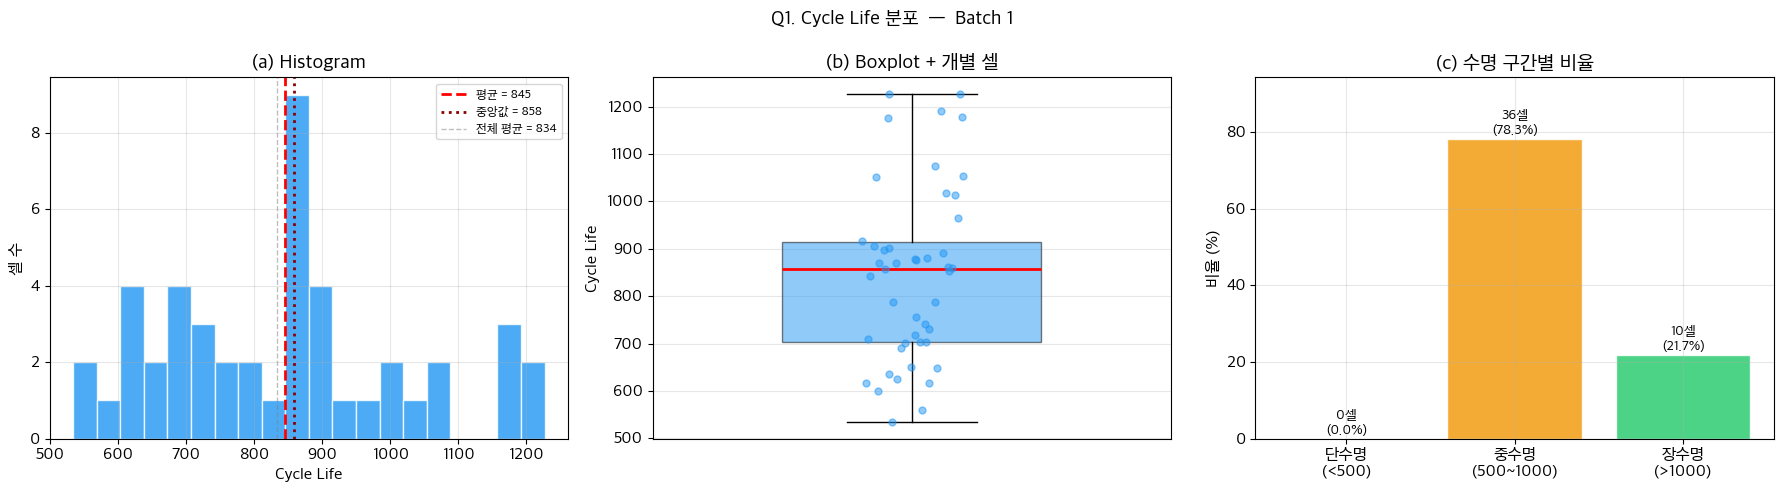


Batch 1  |  n=46  mean=845  std=185  min=534  max=1227


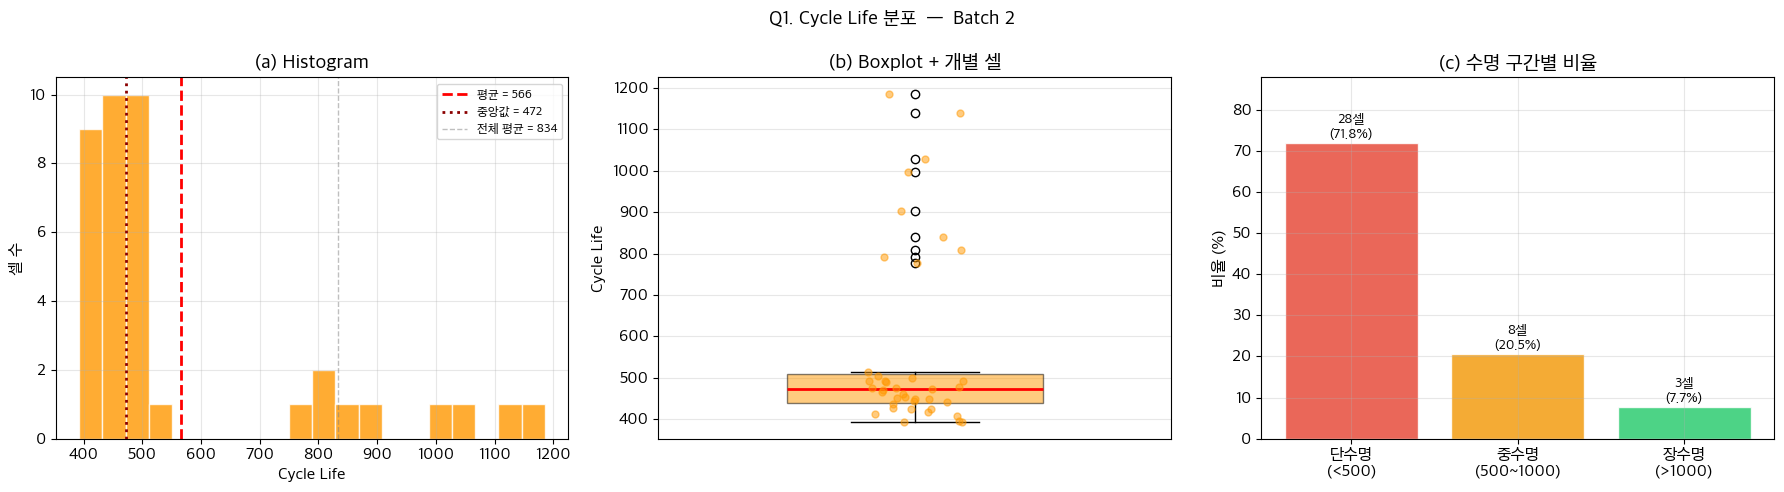


Batch 2  |  n=39  mean=566  std=222  min=392  max=1186
  ⚠ IQR 이상치 → Batch 2_cell07  CL=777  policy=4.8C(80%)-4.8C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell08  CL=904  policy=5.2C(58%)-4C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell09  CL=791  policy=5.6C(26%)-4.5C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell30  CL=809  policy=4.8C(80%)-4.8C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell31  CL=1140  policy=5.2C(58%)-4C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell32  CL=1186  policy=5.6C(26%)-4.5C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell35  CL=1029  policy=4.8C(80%)-4.8C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell36  CL=841  policy=5.2C(58%)-4C-newstructure
  ⚠ IQR 이상치 → Batch 2_cell37  CL=997  policy=5.6C(26%)-4.5C-newstructure


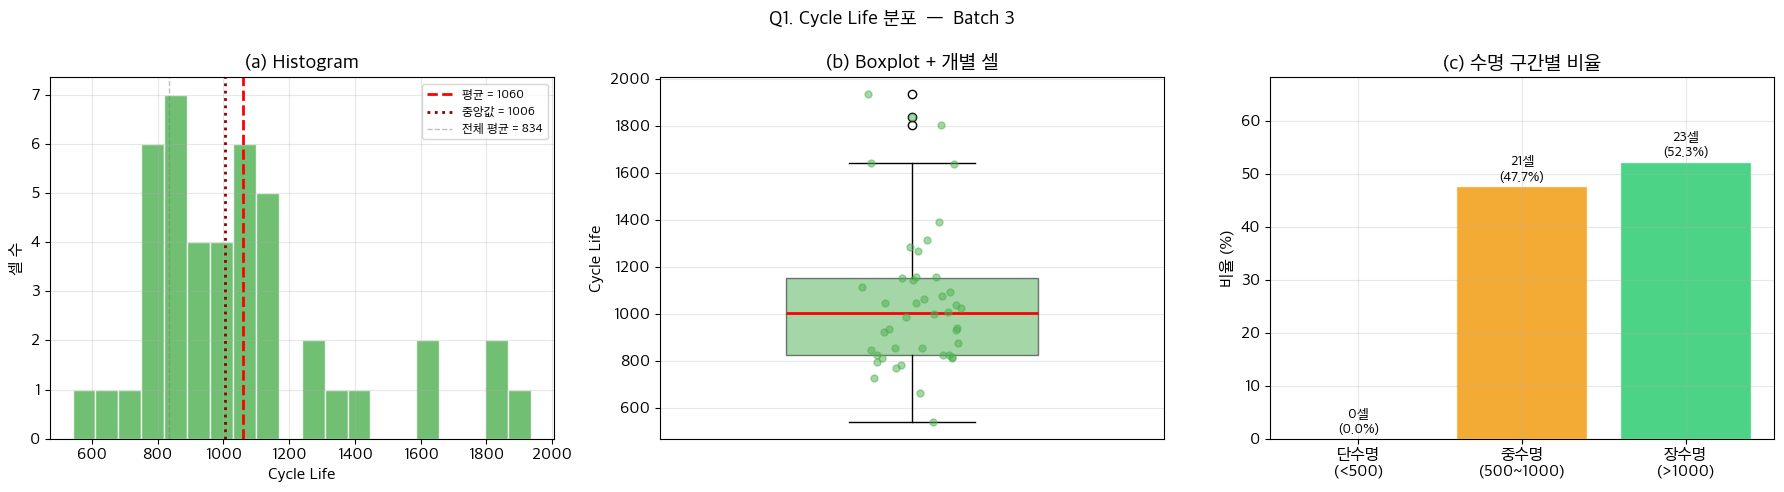


Batch 3  |  n=44  mean=1060  std=314  min=541  max=1935
  ⚠ IQR 이상치 → Batch 3_cell07  CL=1836  policy=4.8C(80%)-4.8C-newstructure
  ⚠ IQR 이상치 → Batch 3_cell36  CL=1935  policy=5C(67%)-4C-newstructure
  ⚠ IQR 이상치 → Batch 3_cell43  CL=1801  policy=4.8C(80%)-4.8C-newstructure


In [6]:
def plot_q1_cycle_life(bname, cell_info_all, save=True):
    cl_b   = cell_info_all[cell_info_all['batch'] == bname]['cycle_life']
    cl_all = cell_info_all['cycle_life']
    color  = BATCH_COLORS[bname]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Q1. Cycle Life 분포  —  {bname}',
                 fontsize=14, fontweight='bold')

    # (a) Histogram
    ax = axes[0]
    ax.hist(cl_b, bins=20, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(cl_b.mean(),   color='red',     ls='--', lw=2,
               label=f'평균 = {cl_b.mean():.0f}')
    ax.axvline(cl_b.median(), color='darkred', ls=':',  lw=2,
               label=f'중앙값 = {cl_b.median():.0f}')
    ax.axvline(cl_all.mean(), color='gray',    ls='--', lw=1, alpha=0.5,
               label=f'전체 평균 = {cl_all.mean():.0f}')
    ax.set_xlabel('Cycle Life')
    ax.set_ylabel('셀 수')
    ax.set_title('(a) Histogram')
    ax.legend(fontsize=9)

    # (b) Boxplot + 개별 셀
    ax = axes[1]
    bp = ax.boxplot(cl_b, patch_artist=True, widths=0.5,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.5)
    jitter = np.random.uniform(-0.1, 0.1, len(cl_b))
    ax.scatter(np.ones(len(cl_b)) + jitter, cl_b,
               alpha=0.5, color=color, s=25, zorder=3)
    ax.set_xticks([])
    ax.set_ylabel('Cycle Life')
    ax.set_title('(b) Boxplot + 개별 셀')

    # (c) 수명 구간 비율
    ax = axes[2]
    total = len(cl_b)
    short = (cl_b < 500).sum()
    mid   = ((cl_b >= 500) & (cl_b <= 1000)).sum()
    long_ = (cl_b > 1000).sum()
    bars  = ax.bar(['단수명\n(<500)', '중수명\n(500~1000)', '장수명\n(>1000)'],
                   [short/total*100, mid/total*100, long_/total*100],
                   color=['#e74c3c','#f39c12','#2ecc71'],
                   alpha=0.85, edgecolor='white')
    for bar, n in zip(bars, [short, mid, long_]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{n}셀\n({n/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)
    ax.set_ylabel('비율 (%)')
    ax.set_title('(c) 수명 구간별 비율')
    ax.set_ylim(0, max(short, mid, long_)/total*100 + 16)

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q1_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    # 이상치 보고
    Q1r, Q3r = cl_b.quantile(0.25), cl_b.quantile(0.75)
    IQR = Q3r - Q1r
    outs = cell_info_all[(cell_info_all['batch'] == bname) &
                         ((cell_info_all['cycle_life'] < Q1r - 1.5*IQR) |
                          (cell_info_all['cycle_life'] > Q3r + 1.5*IQR))]
    print(f'\n{bname}  |  n={total}  mean={cl_b.mean():.0f}  '
          f'std={cl_b.std():.0f}  min={cl_b.min()}  max={cl_b.max()}')
    if len(outs):
        for _, r in outs.iterrows():
            print(f'  ⚠ IQR 이상치 → {r["cell_id"]}  CL={r["cycle_life"]}  '
                  f'policy={r["policy"]}')

for bname in BATCHES:
    plot_q1_cycle_life(bname, cell_info)

---
# Q2-1. 열화 곡선 (QD 감소 패턴)

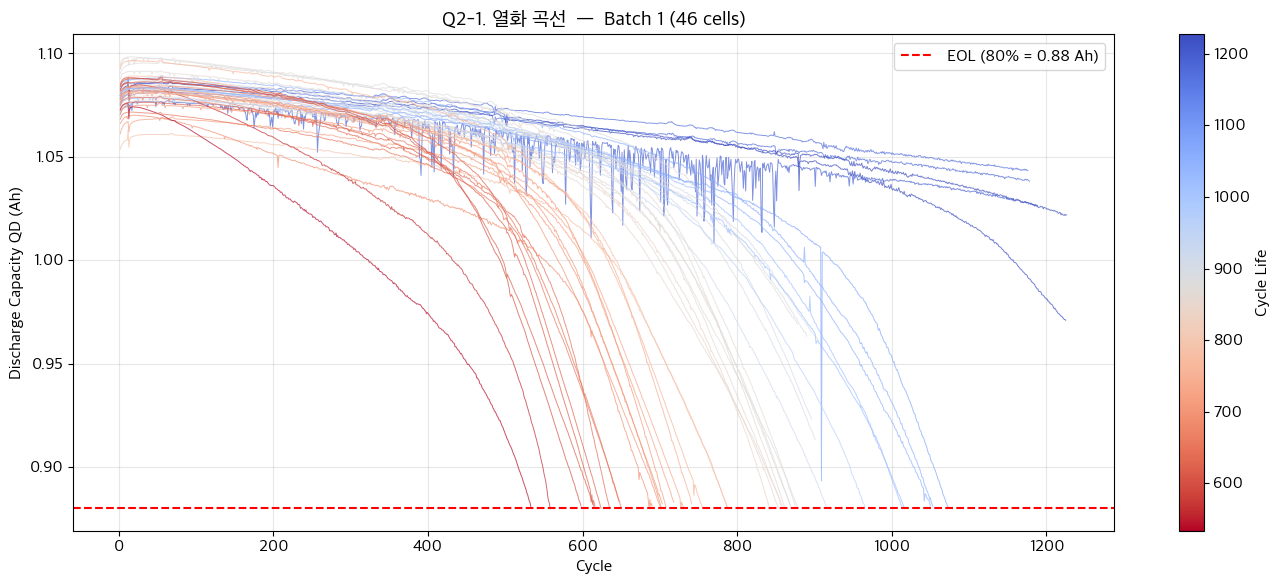

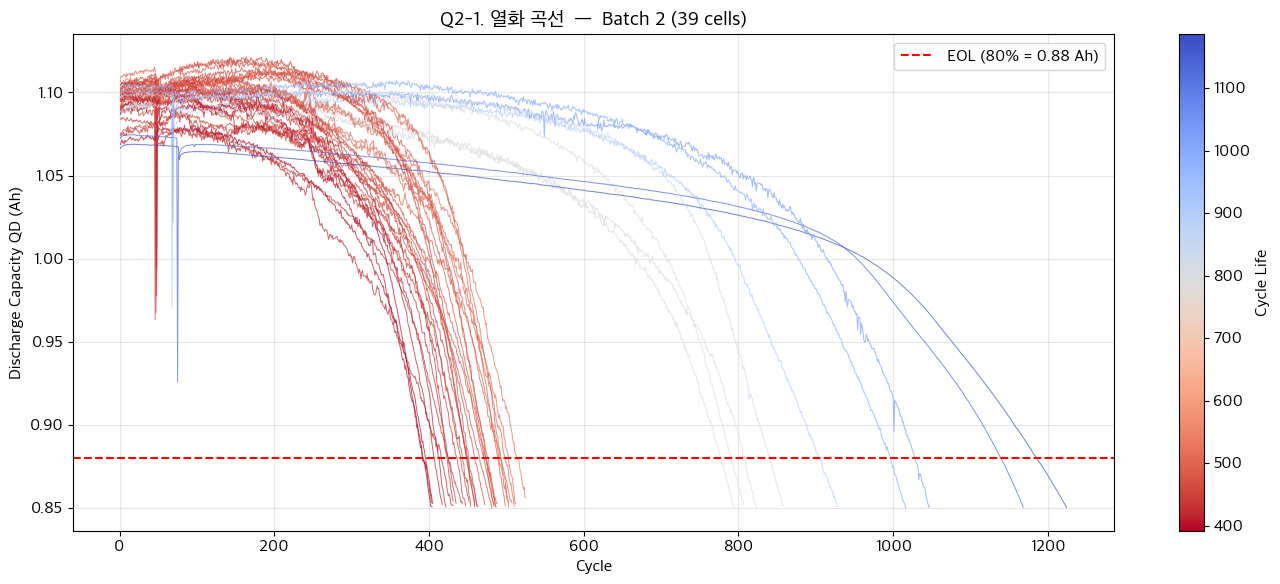

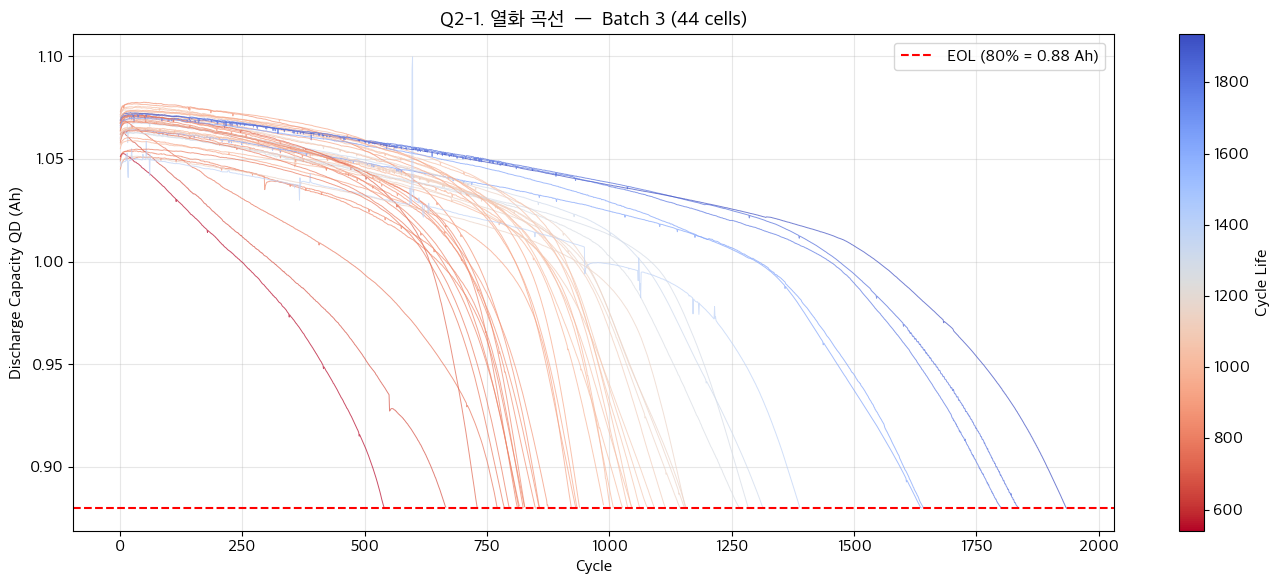

In [7]:
def plot_q2_degradation(bname, df_b, save=True):
    cell_ids = df_b['cell_id'].unique()
    cl_map   = df_b.drop_duplicates('cell_id').set_index('cell_id')['cycle_life']
    norm     = plt.Normalize(cl_map.min(), cl_map.max())
    cmap     = cm.coolwarm_r

    fig, ax = plt.subplots(figsize=(14, 6))
    for cid in cell_ids:
        sub   = df_b[(df_b['cell_id'] == cid) & (df_b['QD'].between(0.85, 1.15))]
        color = cmap(norm(cl_map[cid]))
        ax.plot(sub['cycle'], sub['QD'], color=color, lw=0.7, alpha=0.7)

    ax.axhline(0.88, color='red', ls='--', lw=1.5, label='EOL (80% = 0.88 Ah)')
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Cycle Life')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Discharge Capacity QD (Ah)')
    ax.set_title(f'Q2-1. 열화 곡선  —  {bname} ({len(cell_ids)} cells)')
    ax.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q2_degradation_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

for bname in BATCHES:
    plot_q2_degradation(bname, batch_dfs[bname])

# Q2-2. QD 이상치(튀는 값) 식별

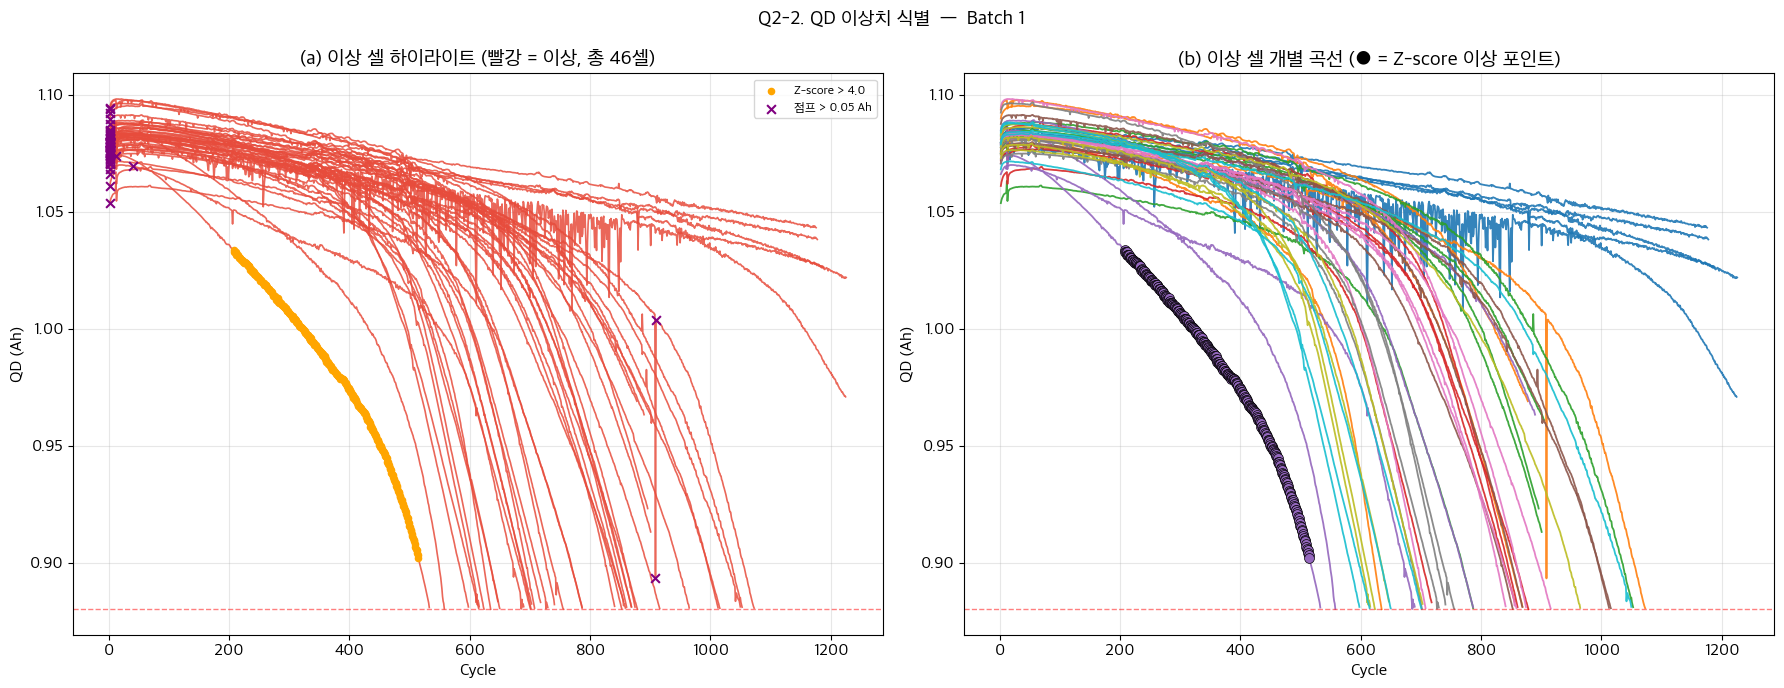


=== Batch 1 QD 이상치 요약 ===
  Z-score>4.0: 310포인트  (3셀)
  점프>0.05Ah: 52포인트  (46셀)
  → Batch 1_cell00  CL=1190  3.6C(80%)-3.6C
     Z이상=1개  점프=3개  최대점프=1.0707Ah
  → Batch 1_cell01  CL=1179  3.6C(80%)-3.6C
     Z이상=0개  점프=1개  최대점프=1.0753Ah
  → Batch 1_cell02  CL=1177  3.6C(80%)-3.6C
     Z이상=0개  점프=1개  최대점프=1.0799Ah
  → Batch 1_cell03  CL=1226  4C(80%)-4C
     Z이상=0개  점프=1개  최대점프=1.0797Ah
  → Batch 1_cell04  CL=1227  4C(80%)-4C
     Z이상=0개  점프=1개  최대점프=1.0784Ah
  → Batch 1_cell05  CL=1074  4.4C(80%)-4.4C
     Z이상=0개  점프=3개  최대점프=1.0761Ah
  → Batch 1_cell06  CL=636  4.8C(80%)-4.8C
     Z이상=0개  점프=1개  최대점프=1.0758Ah
  → Batch 1_cell07  CL=870  4.8C(80%)-4.8C
     Z이상=0개  점프=1개  최대점프=1.0939Ah
  → Batch 1_cell08  CL=879  5.4C(40%)-3.6C
     Z이상=0개  점프=1개  최대점프=1.0900Ah
  → Batch 1_cell09  CL=1054  5.4C(40%)-3.6C
     Z이상=0개  점프=1개  최대점프=1.0830Ah
  → Batch 1_cell10  CL=906  5.4C(50%)-3C
     Z이상=0개  점프=1개  최대점프=1.0753Ah
  → Batch 1_cell11  CL=788  5.4C(50%)-3C
     Z이상=0개  점프=1개  최대점프=1.0538Ah


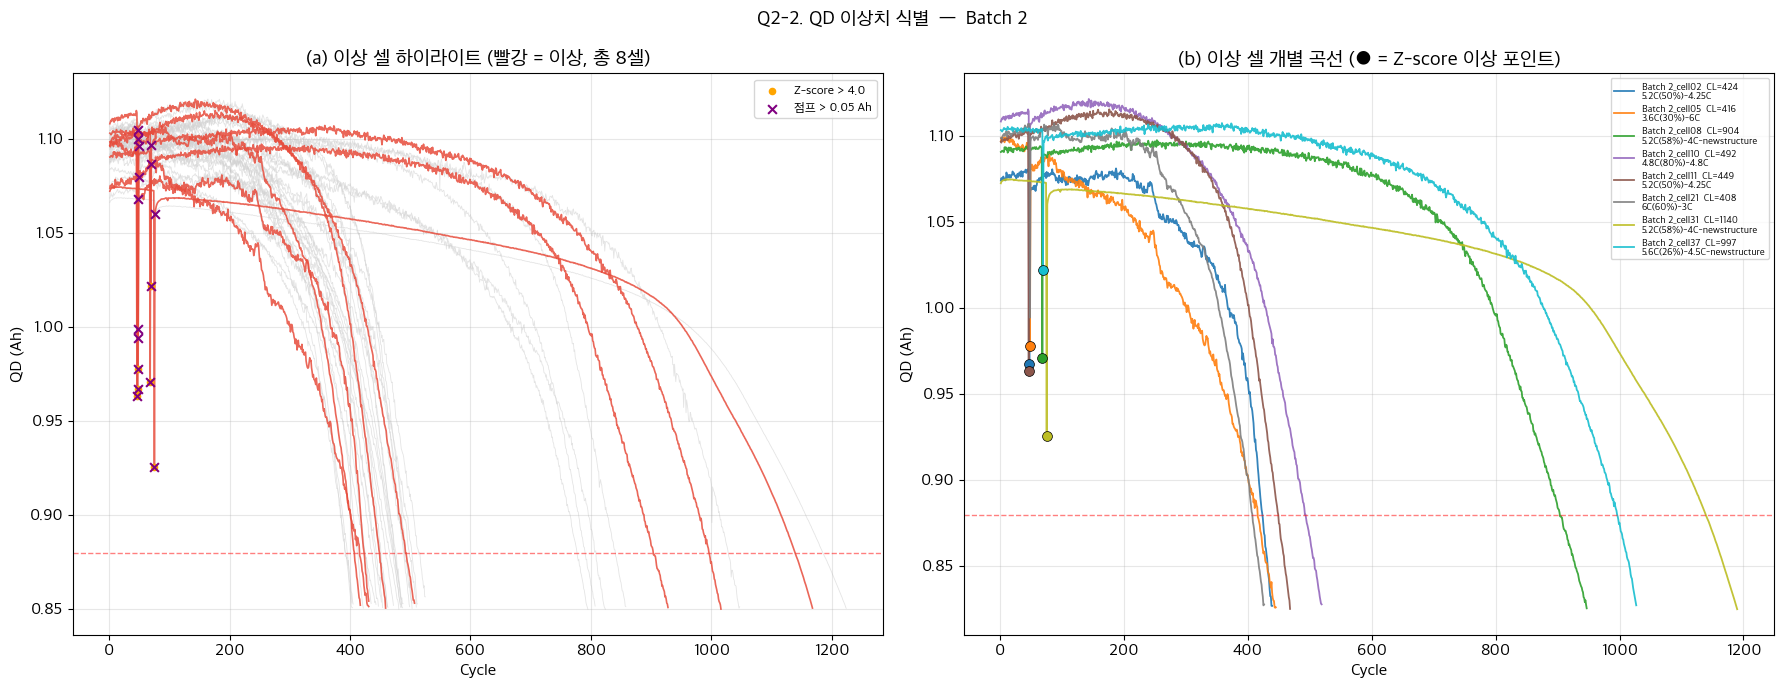


=== Batch 2 QD 이상치 요약 ===
  Z-score>4.0: 6포인트  (6셀)
  점프>0.05Ah: 16포인트  (8셀)
  → Batch 2_cell02  CL=424  5.2C(50%)-4.25C
     Z이상=1개  점프=2개  최대점프=0.1120Ah
  → Batch 2_cell05  CL=416  3.6C(30%)-6C
     Z이상=1개  점프=2개  최대점프=0.1145Ah
  → Batch 2_cell08  CL=904  5.2C(58%)-4C-newstructure
     Z이상=1개  점프=2개  최대점프=0.1218Ah
  → Batch 2_cell10  CL=492  4.8C(80%)-4.8C
     Z이상=0개  점프=2개  최대점프=0.1151Ah
  → Batch 2_cell11  CL=449  5.2C(50%)-4.25C
     Z이상=1개  점프=2개  최대점프=0.1390Ah
  → Batch 2_cell21  CL=408  6C(60%)-3C
     Z이상=0개  점프=2개  최대점프=0.1124Ah
  → Batch 2_cell31  CL=1140  5.2C(58%)-4C-newstructure
     Z이상=1개  점프=2개  최대점프=0.1469Ah
  → Batch 2_cell37  CL=997  5.6C(26%)-4.5C-newstructure
     Z이상=1개  점프=2개  최대점프=0.0819Ah


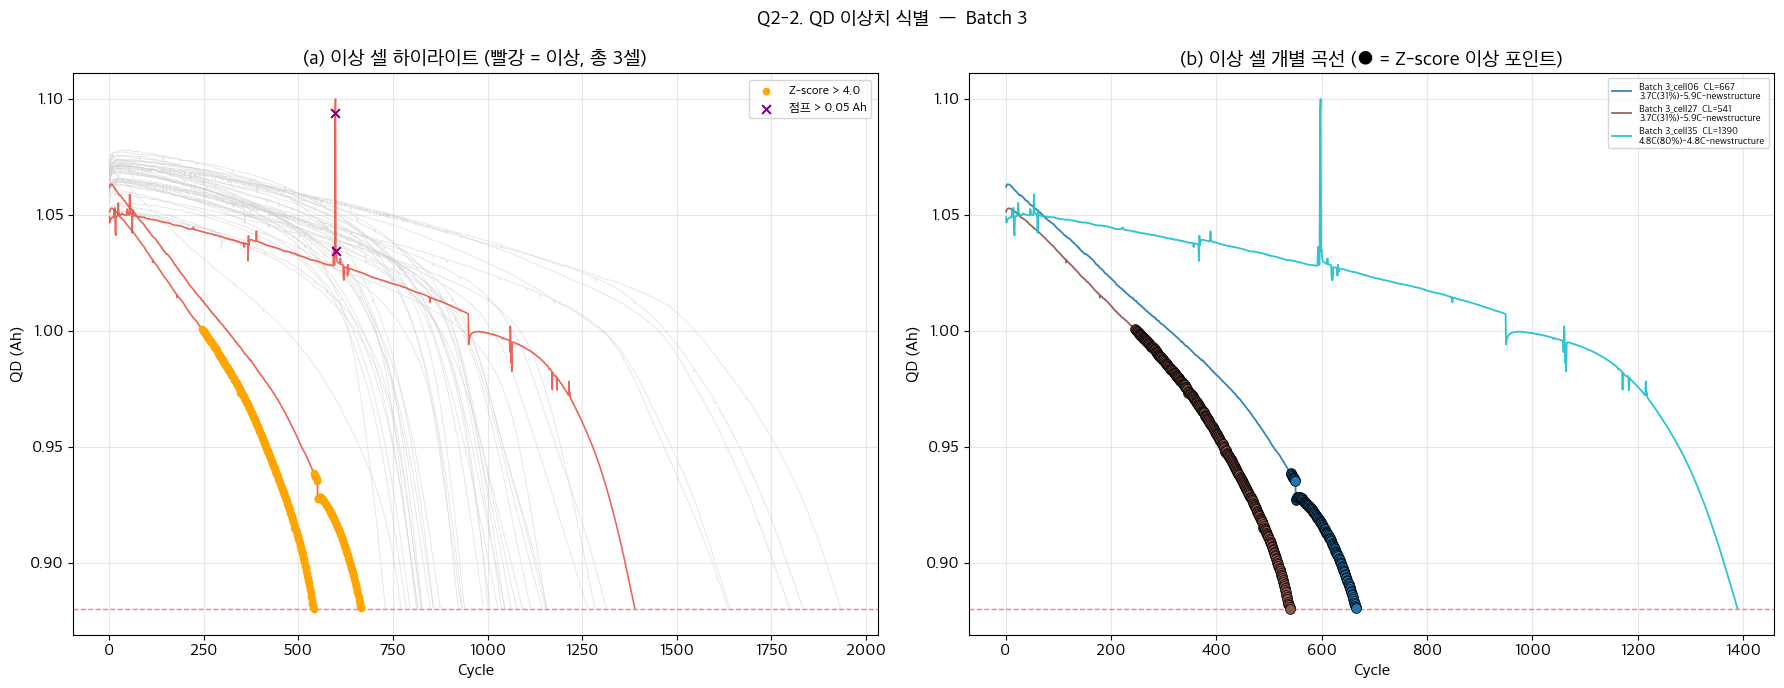


=== Batch 3 QD 이상치 요약 ===
  Z-score>4.0: 420포인트  (2셀)
  점프>0.05Ah: 2포인트  (1셀)
  → Batch 3_cell06  CL=667  3.7C(31%)-5.9C-newstructure
     Z이상=126개  점프=0개  최대점프=0.0080Ah
  → Batch 3_cell27  CL=541  3.7C(31%)-5.9C-newstructure
     Z이상=294개  점프=0개  최대점프=0.0018Ah
  → Batch 3_cell35  CL=1390  4.8C(80%)-4.8C-newstructure
     Z이상=0개  점프=2개  최대점프=0.0657Ah


In [8]:
def detect_qd_anomalies(df_b, bname,
                         z_thresh=4.0,
                         jump_thresh=0.05,
                         save=True):
    """
    QD 이상치 탐지
      방법 1: cycle별 Z-score > z_thresh
      방법 2: 연속 사이클 간 급격한 점프 |ΔQD| > jump_thresh
    """
    df_b = df_b.copy().sort_values(['cell_id', 'cycle'])

    # 방법 1: cycle별 Z-score
    cyc_stats = (df_b[df_b['QD'].between(0.7, 1.2)]
                 .groupby('cycle')['QD']
                 .agg(['mean','std'])
                 .rename(columns={'mean':'cyc_mean','std':'cyc_std'}))
    df_b = df_b.join(cyc_stats, on='cycle')
    df_b['qd_zscore'] = ((df_b['QD'] - df_b['cyc_mean'])
                         / df_b['cyc_std'].replace(0, np.nan)).abs()
    z_out = df_b[df_b['qd_zscore'] > z_thresh].copy()

    # 방법 2: 연속 점프
    df_b['qd_diff'] = df_b.groupby('cell_id')['QD'].diff().abs()
    j_out = df_b[df_b['qd_diff'] > jump_thresh].copy()

    anom_cells = set(z_out['cell_id']) | set(j_out['cell_id'])
    cl_map = df_b.drop_duplicates('cell_id').set_index('cell_id')['cycle_life']

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Q2-2. QD 이상치 식별  —  {bname}',
                 fontsize=14, fontweight='bold')

    # (a) 전체 + 이상 셀 하이라이트
    ax = axes[0]
    for cid in df_b['cell_id'].unique():
        sub = df_b[(df_b['cell_id'] == cid) & (df_b['QD'].between(0.85, 1.15))]
        if cid in anom_cells:
            ax.plot(sub['cycle'], sub['QD'],
                    color='#e74c3c', lw=1.2, alpha=0.85, zorder=3)
        else:
            ax.plot(sub['cycle'], sub['QD'],
                    color='lightgray', lw=0.6, alpha=0.6, zorder=1)

    # Z-score 이상 포인트
    zp = z_out[z_out['QD'].between(0.5, 1.3)]
    ax.scatter(zp['cycle'], zp['QD'], color='orange', s=20, zorder=5,
               label=f'Z-score > {z_thresh}')
    # 점프 포인트
    jp = j_out[j_out['QD'].between(0.5, 1.3)]
    ax.scatter(jp['cycle'], jp['QD'], color='purple', marker='x', s=40,
               zorder=6, label=f'점프 > {jump_thresh} Ah')

    ax.axhline(0.88, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Cycle');  ax.set_ylabel('QD (Ah)')
    ax.set_title(f'(a) 이상 셀 하이라이트 (빨강 = 이상, 총 {len(anom_cells)}셀)')
    ax.legend(fontsize=9)

    # (b) 이상 셀 개별 곡선
    ax = axes[1]
    pal = plt.cm.tab10(np.linspace(0, 1, max(len(anom_cells), 1)))
    for i, cid in enumerate(sorted(anom_cells)):
        sub  = df_b[(df_b['cell_id'] == cid) & (df_b['QD'].between(0.5, 1.3))]
        cl   = cl_map.get(cid, '?')
        pol  = df_b[df_b['cell_id'] == cid]['policy'].iloc[0]
        ax.plot(sub['cycle'], sub['QD'], color=pal[i % len(pal)], lw=1.3,
                label=f'{cid}  CL={cl}\n{pol}', alpha=0.9)
        # Z-score 이상 포인트 표시
        zpts = z_out[(z_out['cell_id'] == cid) & (z_out['QD'].between(0.5, 1.3))]
        if len(zpts):
            ax.scatter(zpts['cycle'], zpts['QD'],
                       color=pal[i % len(pal)], s=50, zorder=5,
                       edgecolors='black', lw=0.5)

    ax.axhline(0.88, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Cycle');  ax.set_ylabel('QD (Ah)')
    ax.set_title('(b) 이상 셀 개별 곡선 (● = Z-score 이상 포인트)')
    if len(anom_cells) <= 12:
        ax.legend(fontsize=7)

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q2_anomaly_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    # 상세 보고
    print(f'\n=== {bname} QD 이상치 요약 ===')
    print(f'  Z-score>{z_thresh}: {len(z_out)}포인트  '
          f'({z_out["cell_id"].nunique()}셀)')
    print(f'  점프>{jump_thresh}Ah: {len(j_out)}포인트  '
          f'({j_out["cell_id"].nunique()}셀)')
    for cid in sorted(anom_cells):
        pol      = df_b[df_b['cell_id'] == cid]['policy'].iloc[0]
        nz       = (z_out['cell_id'] == cid).sum()
        nj       = (j_out['cell_id'] == cid).sum()
        max_jump = df_b[df_b['cell_id'] == cid]['qd_diff'].max()
        print(f'  → {cid}  CL={cl_map.get(cid,"?")}  {pol}')
        print(f'     Z이상={nz}개  점프={nj}개  최대점프={max_jump:.4f}Ah')

    return z_out, j_out, anom_cells

anom_results = {}
for bname in BATCHES:
    zo, jo, ac = detect_qd_anomalies(batch_dfs[bname], bname)
    anom_results[bname] = {'zscore': zo, 'jump': jo, 'cells': ac}

# Q2-2b. 점프 이상치 제거 전/후 열화 곡선 비교

보라색 × (연속 점프 > 0.05 Ah) 로 탐지된 데이터 포인트만 제거하고,
원본과 나란히 비교한다.
※ 셀 전체를 삭제하는 것이 아니라, 이상치 **사이클 행**만 제거한다.

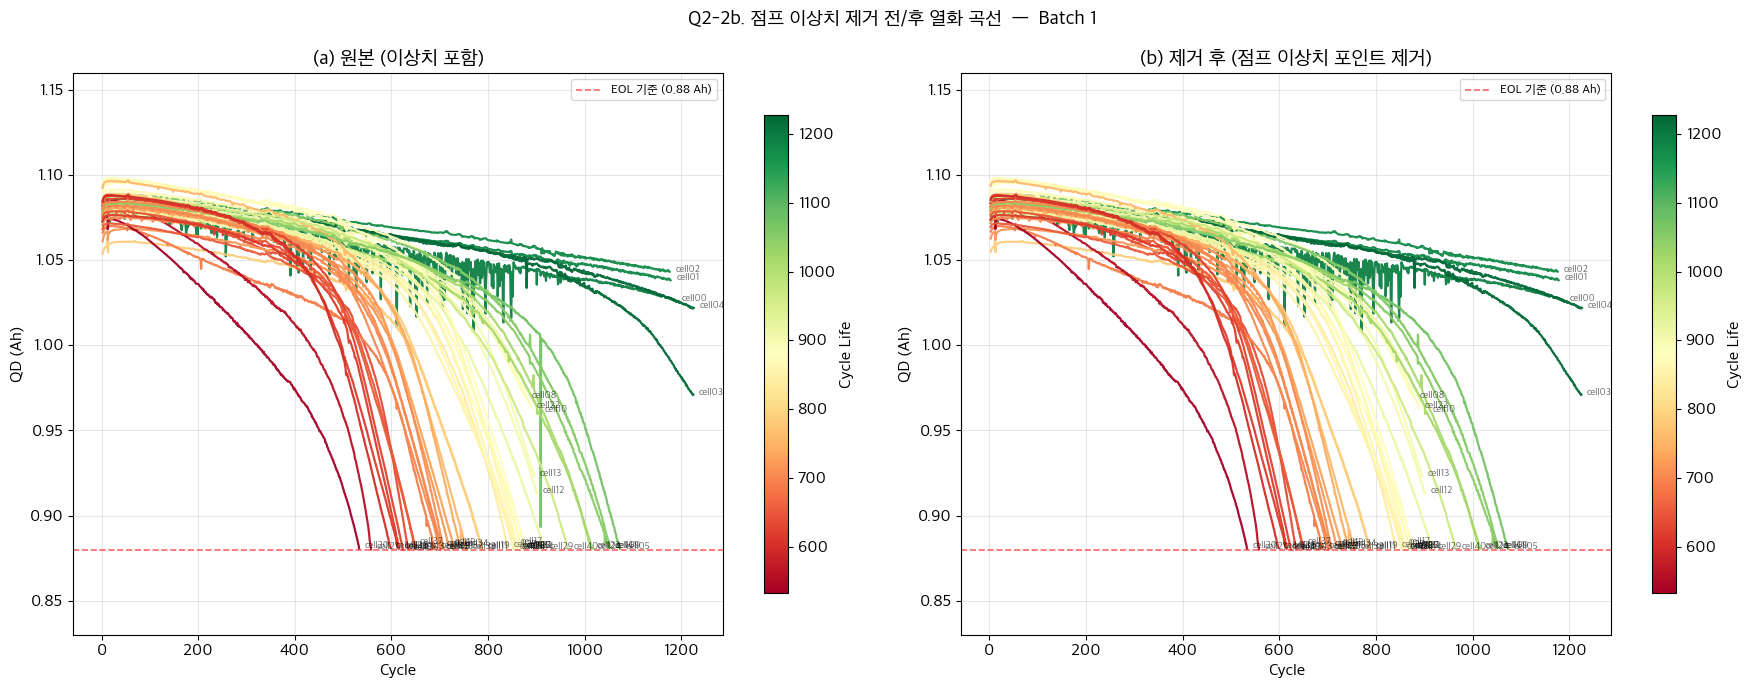


[Batch 1] 점프 이상치 제거 결과
  제거된 포인트 : 52개 / 38811개  (0.13%)
  영향 받은 셀  : 46개
  제거 후 데이터: 38759행
    → Batch 1_cell00  제거=3개
    → Batch 1_cell01  제거=1개
    → Batch 1_cell02  제거=1개
    → Batch 1_cell03  제거=1개
    → Batch 1_cell04  제거=1개
    → Batch 1_cell05  제거=3개
    → Batch 1_cell06  제거=1개
    → Batch 1_cell07  제거=1개
    → Batch 1_cell08  제거=1개
    → Batch 1_cell09  제거=1개
    → Batch 1_cell10  제거=1개
    → Batch 1_cell11  제거=1개
    → Batch 1_cell12  제거=1개
    → Batch 1_cell13  제거=1개
    → Batch 1_cell14  제거=1개
    → Batch 1_cell15  제거=1개
    → Batch 1_cell16  제거=1개
    → Batch 1_cell17  제거=1개
    → Batch 1_cell18  제거=3개
    → Batch 1_cell19  제거=1개
    → Batch 1_cell20  제거=1개
    → Batch 1_cell21  제거=1개
    → Batch 1_cell22  제거=1개
    → Batch 1_cell23  제거=1개
    → Batch 1_cell24  제거=1개
    → Batch 1_cell25  제거=1개
    → Batch 1_cell26  제거=1개
    → Batch 1_cell27  제거=1개
    → Batch 1_cell28  제거=1개
    → Batch 1_cell29  제거=1개
    → Batch 1_cell30  제거=1개
    → Batch 1_cell31  제거=1개
    → Batc

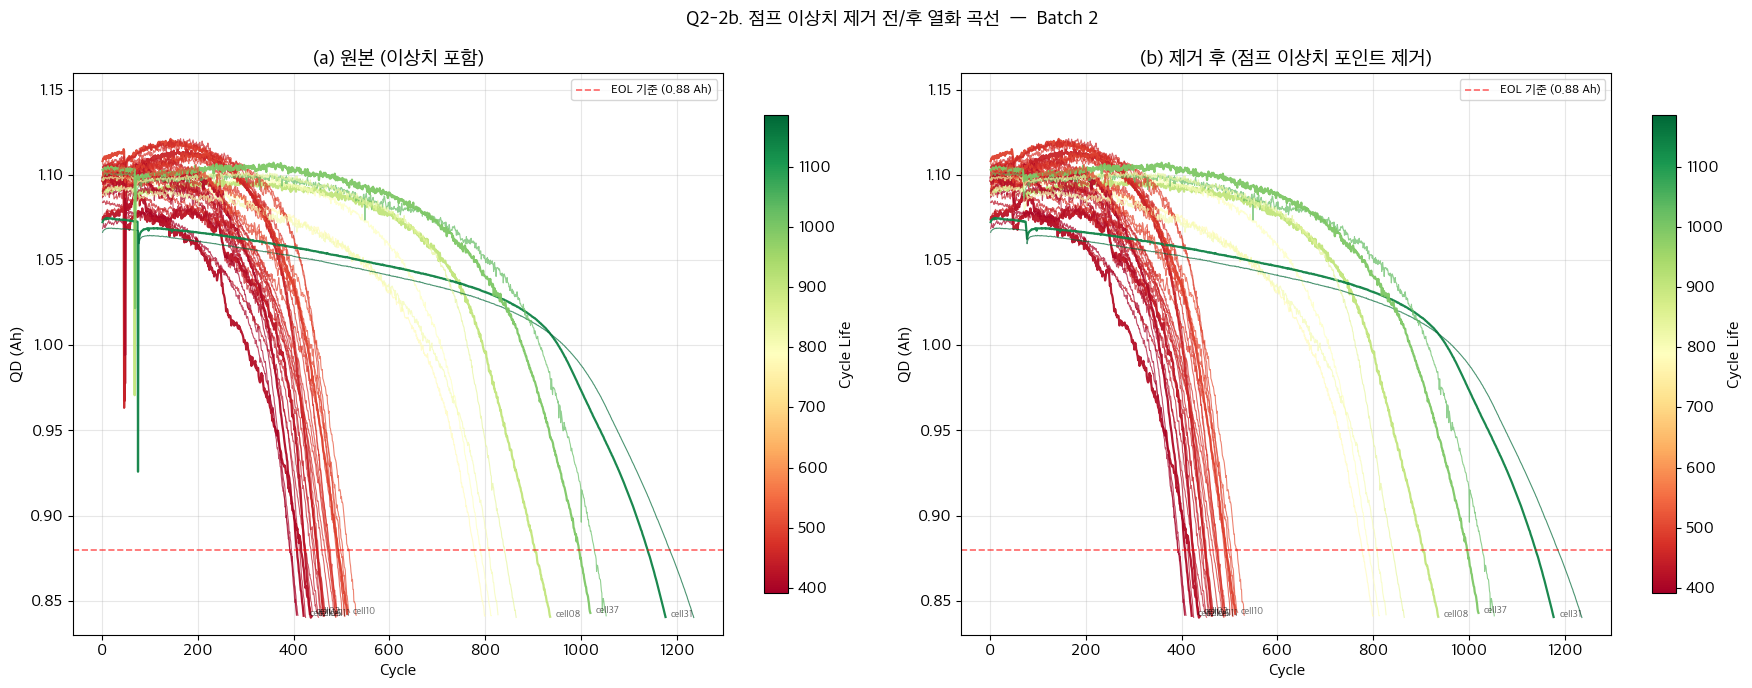


[Batch 2] 점프 이상치 제거 결과
  제거된 포인트 : 16개 / 23034개  (0.07%)
  영향 받은 셀  : 8개
  제거 후 데이터: 23018행
    → Batch 2_cell02  제거=2개
    → Batch 2_cell05  제거=2개
    → Batch 2_cell08  제거=2개
    → Batch 2_cell10  제거=2개
    → Batch 2_cell11  제거=2개
    → Batch 2_cell21  제거=2개
    → Batch 2_cell31  제거=2개
    → Batch 2_cell37  제거=2개


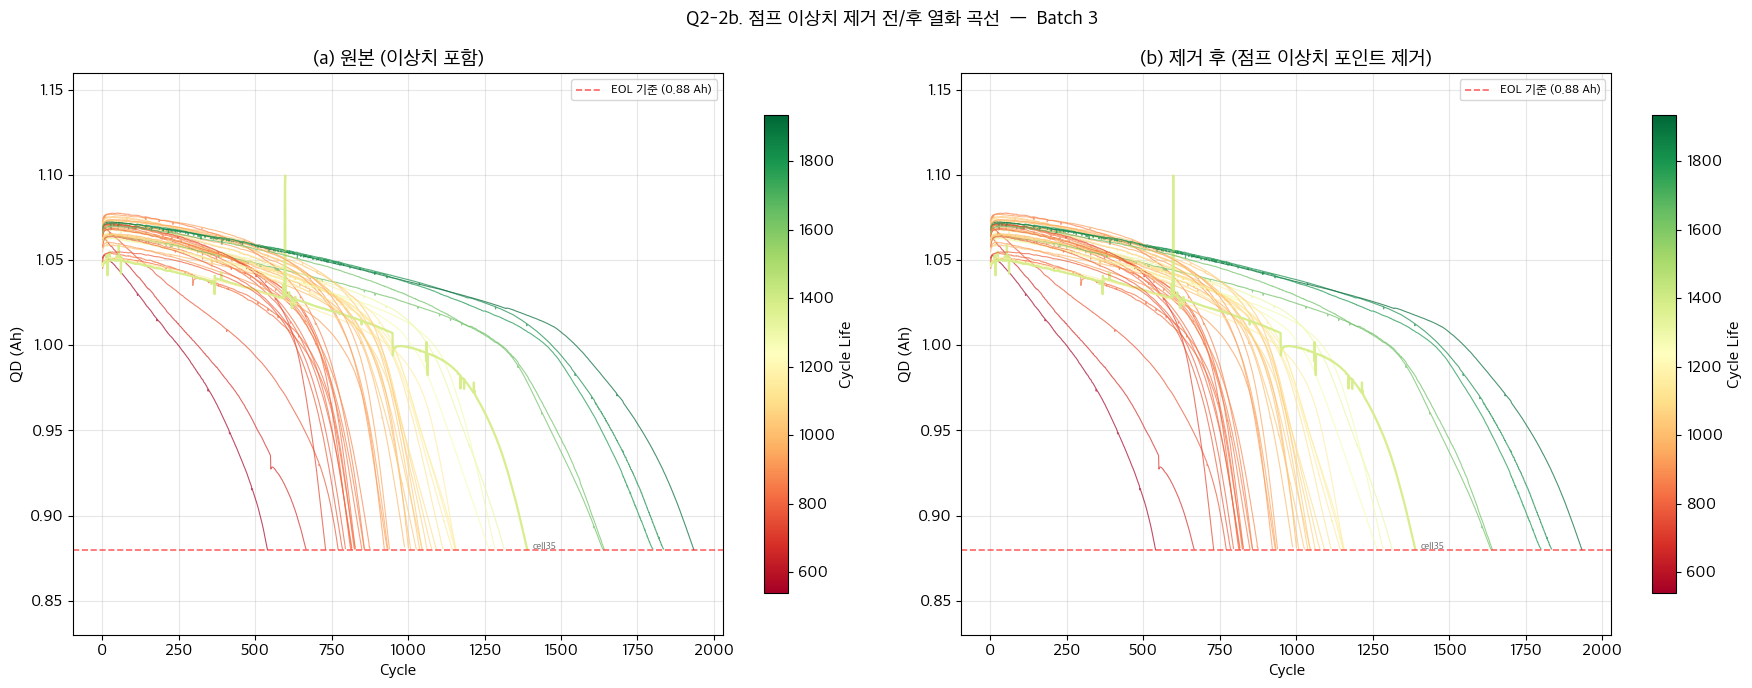


[Batch 3] 점프 이상치 제거 결과
  제거된 포인트 : 2개 / 46581개  (0.00%)
  영향 받은 셀  : 1개
  제거 후 데이터: 46579행
    → Batch 3_cell35  제거=2개


In [ ]:
def plot_q2_cleaned_degradation(bname, df_b, j_out, save=True):
    """
    점프 이상치(|ΔQD| > 0.05 Ah) 행을 제거한 후 열화 곡선을 원본과 비교
    ※ (cell_id, cycle) 쌍 기준으로 해당 행만 제거; 셀 전체 삭제 아님
    """
    import matplotlib.colors as mcolors

    # ── 이상치 행 제거 ──────────────────────────────────────────────────
    if len(j_out) > 0:
        anom_pairs = set(zip(j_out['cell_id'].tolist(), j_out['cycle'].tolist()))
        clean_mask = [(cid, cyc) not in anom_pairs
                      for cid, cyc in zip(df_b['cell_id'].tolist(),
                                          df_b['cycle'].tolist())]
        df_clean = df_b[clean_mask].copy()
    else:
        df_clean = df_b.copy()

    anom_cells = set(j_out['cell_id'].tolist()) if len(j_out) > 0 else set()
    cl_map = dict(zip(df_b.drop_duplicates('cell_id')['cell_id'],
                      df_b.drop_duplicates('cell_id')['cycle_life']))
    cl_vals = list(cl_map.values())
    cl_min, cl_max = float(min(cl_vals)), float(max(cl_vals))

    def get_color(cl_val):
        t = (float(cl_val) - cl_min) / (cl_max - cl_min + 1e-9)
        return plt.colormaps['RdYlGn'](max(0.0, min(1.0, t)))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Q2-2b. 점프 이상치 제거 전/후 열화 곡선  —  {bname}',
                 fontsize=14, fontweight='bold')

    panel_data = [
        ('(a) 원본 (이상치 포함)',                df_b),
        ('(b) 제거 후 (점프 이상치 포인트 제거)', df_clean),
    ]

    for ax, (title, df_plot) in zip(axes, panel_data):
        for cid in df_plot['cell_id'].unique():
            sub = df_plot[(df_plot['cell_id'] == cid) &
                          (df_plot['QD'].between(0.84, 1.16))]
            if len(sub) == 0:
                continue
            color = get_color(cl_map.get(cid, cl_min))
            lw    = 1.6 if cid in anom_cells else 0.8
            alpha = 0.95 if cid in anom_cells else 0.7
            ax.plot(sub['cycle'].values, sub['QD'].values,
                    color=color, lw=lw, alpha=alpha)

        # 이상치 셀 레이블 (오른쪽 끝)
        for cid in sorted(anom_cells):
            sub = df_plot[(df_plot['cell_id'] == cid) &
                          (df_plot['QD'].between(0.84, 1.16))]
            if len(sub) == 0:
                continue
            last = sub.sort_values('cycle').iloc[-1]
            ax.annotate(cid.split('_')[-1],
                        xy=(last['cycle'], last['QD']),
                        fontsize=7, color='black', alpha=0.6,
                        xytext=(4, 0), textcoords='offset points')

        ax.axhline(0.88, color='red', ls='--', lw=1.2, alpha=0.6,
                   label='EOL 기준 (0.88 Ah)')
        ax.set_xlabel('Cycle')
        ax.set_ylabel('QD (Ah)')
        ax.set_title(title)
        ax.set_ylim(0.83, 1.16)
        ax.legend(fontsize=9)

        sm = plt.cm.ScalarMappable(
            cmap=plt.colormaps['RdYlGn'],
            norm=mcolors.Normalize(vmin=cl_min, vmax=cl_max))
        sm.set_array(np.linspace(cl_min, cl_max, 10))
        fig.colorbar(sm, ax=ax, label='Cycle Life', shrink=0.85)

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q2_cleaned_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    # ── 제거 통계 출력 ────────────────────────────────────────────────
    n_removed    = len(j_out)
    n_total      = len(df_b)
    n_anom_cells = len(anom_cells)
    print(f'\n[{bname}] 점프 이상치 제거 결과')
    print(f'  제거된 포인트 : {n_removed}개 / {n_total}개  '
          f'({n_removed / n_total * 100:.2f}%)')
    print(f'  영향 받은 셀  : {n_anom_cells}개')
    print(f'  제거 후 데이터: {len(df_clean)}행')
    for cid in sorted(anom_cells):
        nj = (j_out['cell_id'] == cid).sum()
        print(f'    → {cid}  제거={nj}개')

for bname in BATCHES:
    j_out = anom_results[bname]['jump']
    plot_q2_cleaned_degradation(bname, batch_dfs[bname], j_out)
    
for bname in BATCHES:
    j_out = anom_results[bname]['jump']
    df_b  = batch_dfs[bname]

    # 이상치 행 제거
    if len(j_out) > 0:
        anom_pairs = set(zip(j_out['cell_id'].tolist(), j_out['cycle'].tolist()))
        clean_mask = [(cid, cyc) not in anom_pairs
                      for cid, cyc in zip(df_b['cell_id'].tolist(),
                                          df_b['cycle'].tolist())]
        df_clean = df_b[clean_mask].copy()
    else:
        df_clean = df_b.copy()

    # 저장
    fname = f'ESS/{bname.replace(" ", "_")}_cleaned.csv'
    df_clean.to_csv(fname, index=False)

    n_removed = len(df_b) - len(df_clean)
    print(f'[{bname}] {n_removed}행 제거 → {fname} 저장 완료 ({len(df_clean)}행)')

# Q2-3. 열화 속도 분석 (초기 vs 후기)

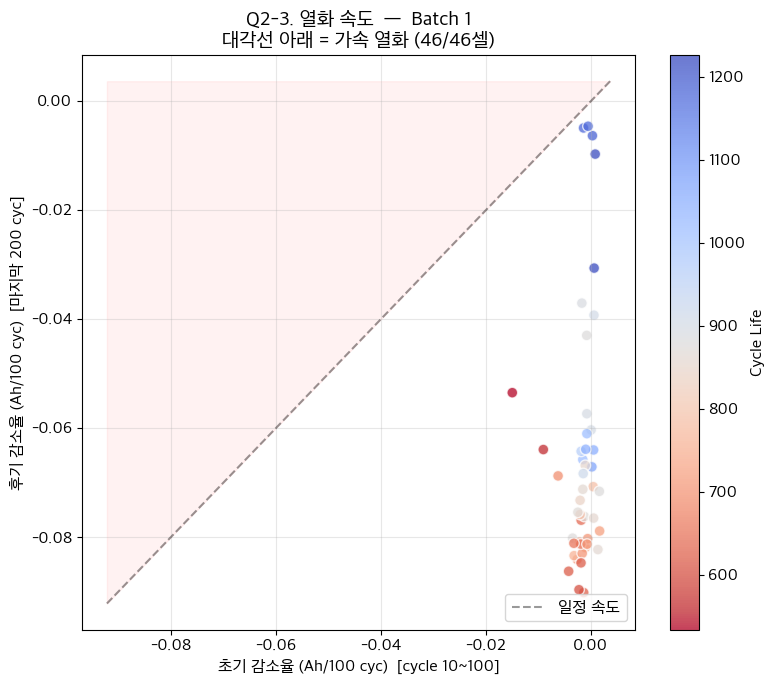

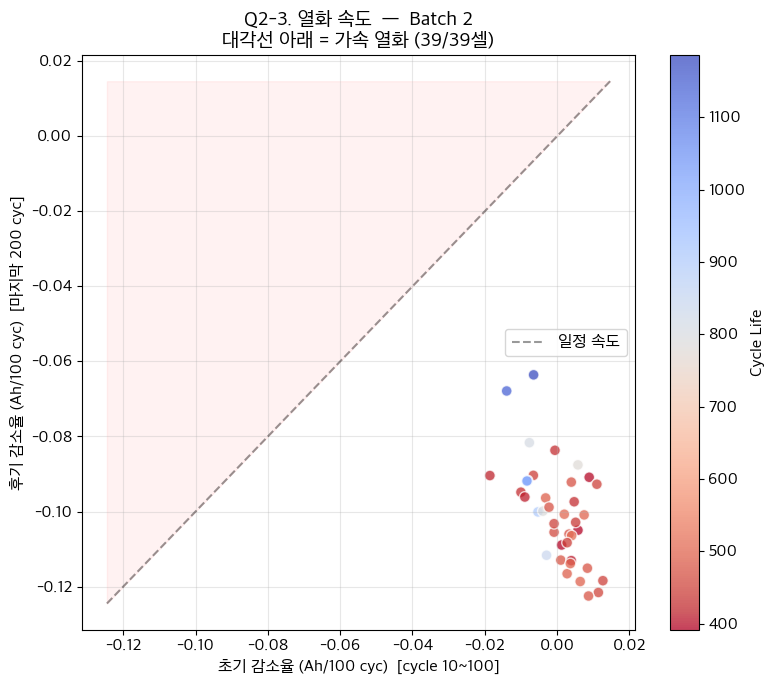

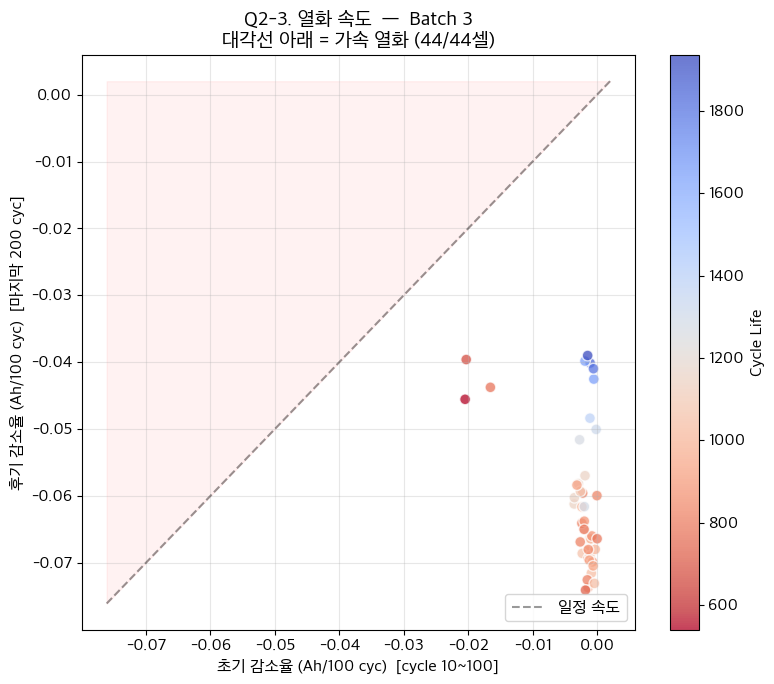

In [10]:
def plot_q2_rate(bname, df_b, save=True):
    early_r, late_r, cl_list = [], [], []

    for cid in df_b['cell_id'].unique():
        sub = df_b[(df_b['cell_id'] == cid) & (df_b['QD'].between(0.85, 1.15))]
        if len(sub) < 100:
            continue
        e = sub[(sub['cycle'] >= 10) & (sub['cycle'] <= 100)]
        l = sub[sub['cycle'] >= sub['cycle'].max() - 200]
        if len(e) > 10 and len(l) > 10:
            early_r.append(np.polyfit(e['cycle'], e['QD'], 1)[0] * 100)
            late_r.append(np.polyfit(l['cycle'],  l['QD'], 1)[0] * 100)
            cl_list.append(sub['cycle_life'].iloc[0])

    early_r = np.array(early_r)
    late_r  = np.array(late_r)
    cl_arr  = np.array(cl_list)

    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(early_r, late_r, c=cl_arr, cmap='coolwarm_r',
                    alpha=0.75, s=60, edgecolors='white')
    plt.colorbar(sc, ax=ax, label='Cycle Life')
    lim = [min(early_r.min(), late_r.min()) - 0.002,
           max(early_r.max(), late_r.max()) + 0.002]
    ax.plot(lim, lim, 'k--', alpha=0.4, label='일정 속도')
    ax.fill_between(lim, lim, [lim[1], lim[1]],
                    alpha=0.05, color='red')
    n_acc = (late_r < early_r).sum()
    ax.set_xlabel('초기 감소율 (Ah/100 cyc)  [cycle 10~100]')
    ax.set_ylabel('후기 감소율 (Ah/100 cyc)  [마지막 200 cyc]')
    ax.set_title(f'Q2-3. 열화 속도  —  {bname}\n'
                 f'대각선 아래 = 가속 열화 ({n_acc}/{len(early_r)}셀)')
    ax.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q2_rate_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

for bname in BATCHES:
    plot_q2_rate(bname, batch_dfs[bname])

# Q2-4. Knee Point 탐지

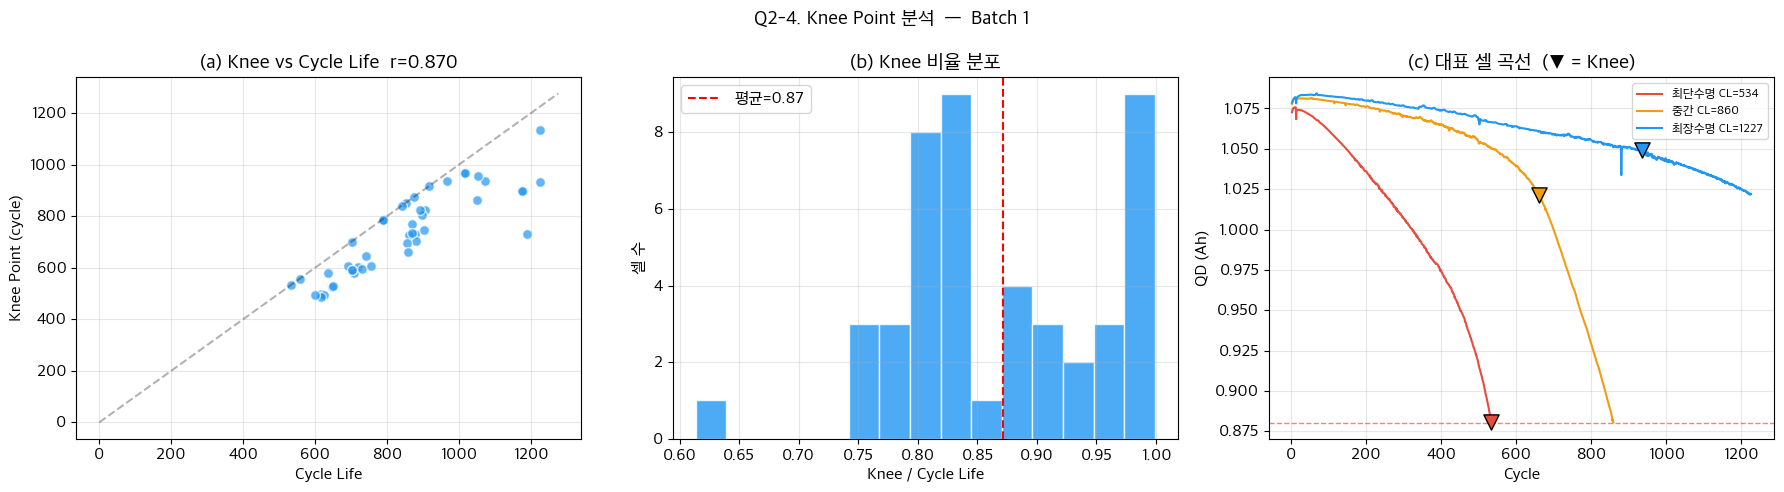

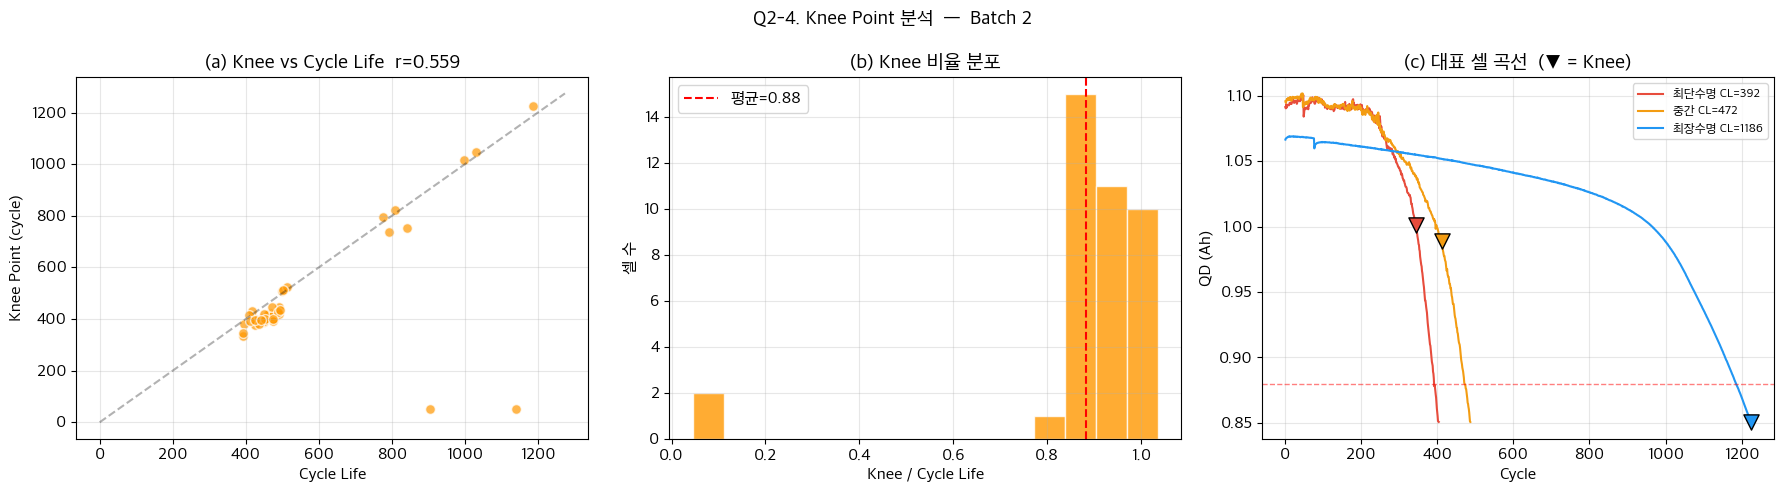

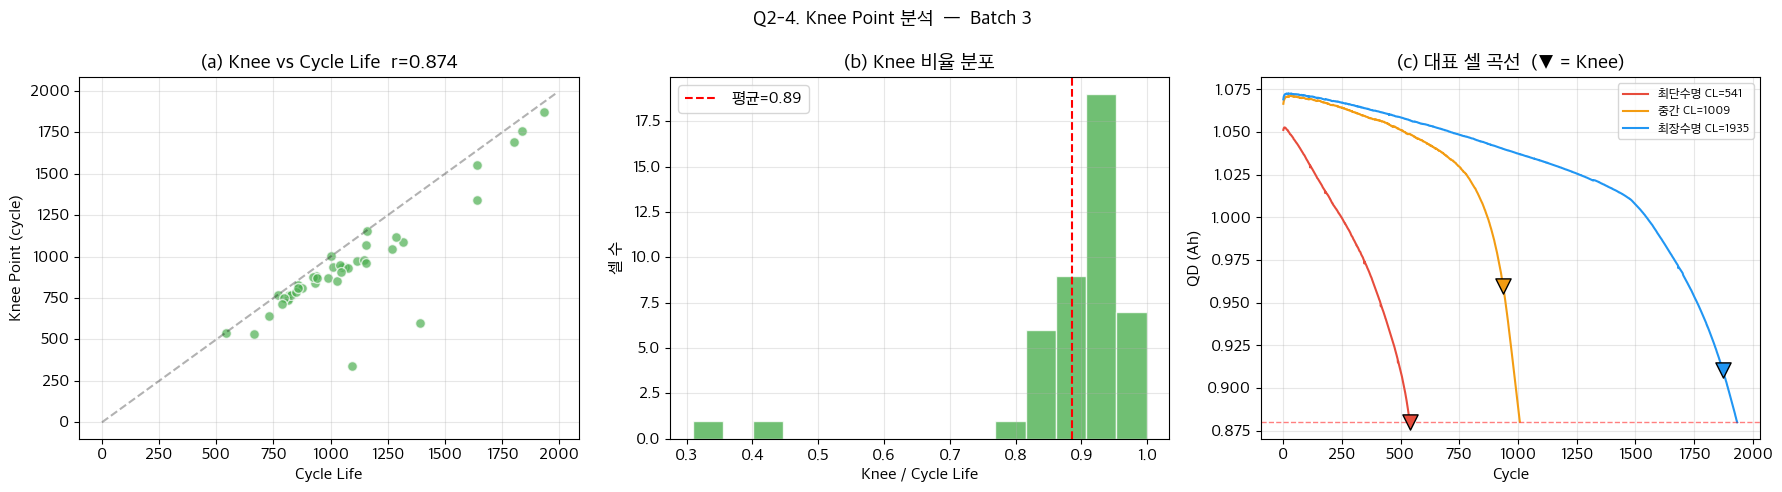

In [11]:
def find_knee_point(cycles, qd, window=51, polyorder=3):
    if len(qd) < window:
        return None
    try:
        qs   = savgol_filter(qd, window, polyorder)
        d2   = savgol_filter(qs,  window, polyorder, deriv=2)
        si   = min(50, len(d2) // 4)
        return cycles[si + np.argmin(d2[si:])]
    except Exception:
        return None

knee_records = []
for bname in BATCHES:
    df_b = batch_dfs[bname]
    for cid in df_b['cell_id'].unique():
        sub  = df_b[(df_b['cell_id'] == cid) & (df_b['QD'].between(0.85, 1.15))]
        if len(sub) < 100:
            continue
        knee = find_knee_point(sub['cycle'].values, sub['QD'].values)
        knee_records.append({'batch': bname, 'cell_id': cid,
                             'cycle_life': sub['cycle_life'].iloc[0],
                             'knee_point': knee})
knee_df = pd.DataFrame(knee_records)
knee_df['knee_ratio'] = knee_df['knee_point'] / knee_df['cycle_life']


def plot_q2_knee(bname, knee_df, df_b, save=True):
    sub_k  = knee_df[knee_df['batch'] == bname]
    cl_map = df_b.drop_duplicates('cell_id').set_index('cell_id')['cycle_life']
    color  = BATCH_COLORS[bname]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Q2-4. Knee Point 분석  —  {bname}',
                 fontsize=14, fontweight='bold')

    # (a) Knee vs CL
    ax = axes[0]
    ax.scatter(sub_k['cycle_life'], sub_k['knee_point'],
               color=color, alpha=0.7, s=50, edgecolors='white')
    lim = max(sub_k['cycle_life'].max(), sub_k['knee_point'].max()) + 50
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3)
    r, _ = stats.pearsonr(sub_k['cycle_life'].dropna(),
                           sub_k['knee_point'].dropna())
    ax.set_xlabel('Cycle Life');  ax.set_ylabel('Knee Point (cycle)')
    ax.set_title(f'(a) Knee vs Cycle Life  r={r:.3f}')

    # (b) Knee Ratio 분포
    ax = axes[1]
    ratio = sub_k['knee_ratio'].dropna()
    ax.hist(ratio, bins=15, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(ratio.mean(), color='red', ls='--', lw=1.5,
               label=f'평균={ratio.mean():.2f}')
    ax.set_xlabel('Knee / Cycle Life')
    ax.set_ylabel('셀 수')
    ax.set_title('(b) Knee 비율 분포')
    ax.legend()

    # (c) 대표 3셀
    ax = axes[2]
    sorted_cells = cl_map.sort_values()
    for idx, lbl, c3 in zip([0, len(sorted_cells)//2, -1],
                              ['최단수명','중간','최장수명'],
                              ['#e74c3c','#f39c12','#2196F3']):
        cid = sorted_cells.index[idx]
        sub = df_b[(df_b['cell_id'] == cid) & (df_b['QD'].between(0.85, 1.15))]
        ax.plot(sub['cycle'], sub['QD'], color=c3, lw=1.5,
                label=f'{lbl} CL={cl_map[cid]}')
        kr = sub_k[sub_k['cell_id'] == cid]
        if len(kr) and pd.notna(kr.iloc[0]['knee_point']):
            kp  = int(kr.iloc[0]['knee_point'])
            kqd = sub[sub['cycle'] == kp]['QD']
            if len(kqd):
                ax.scatter(kp, kqd.values[0], color=c3,
                           marker='v', s=120, zorder=5, edgecolors='black')
    ax.axhline(0.88, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Cycle');  ax.set_ylabel('QD (Ah)')
    ax.set_title('(c) 대표 셀 곡선  (▼ = Knee)')
    ax.legend(fontsize=9)

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q2_knee_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

for bname in BATCHES:
    plot_q2_knee(bname, knee_df, batch_dfs[bname])

# Q2-5. 내부 저항(IR) 추이 분석

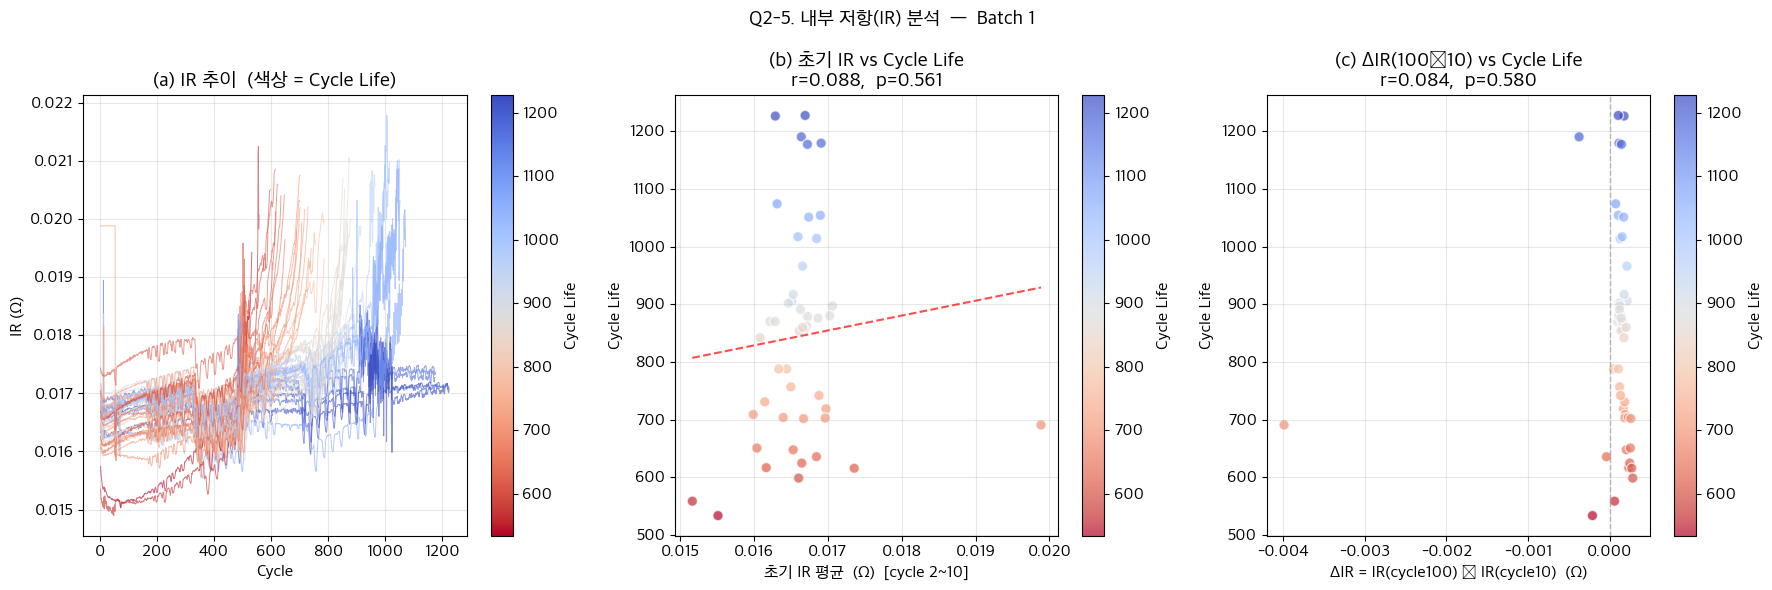


Batch 1 IR 분석:
  초기 IR 범위: 0.0152 ~ 0.0199 Ω
  초기 IR vs CL : r=0.0879,  p=0.5615
  ΔIR   vs CL : r=0.0838,  p=0.5800


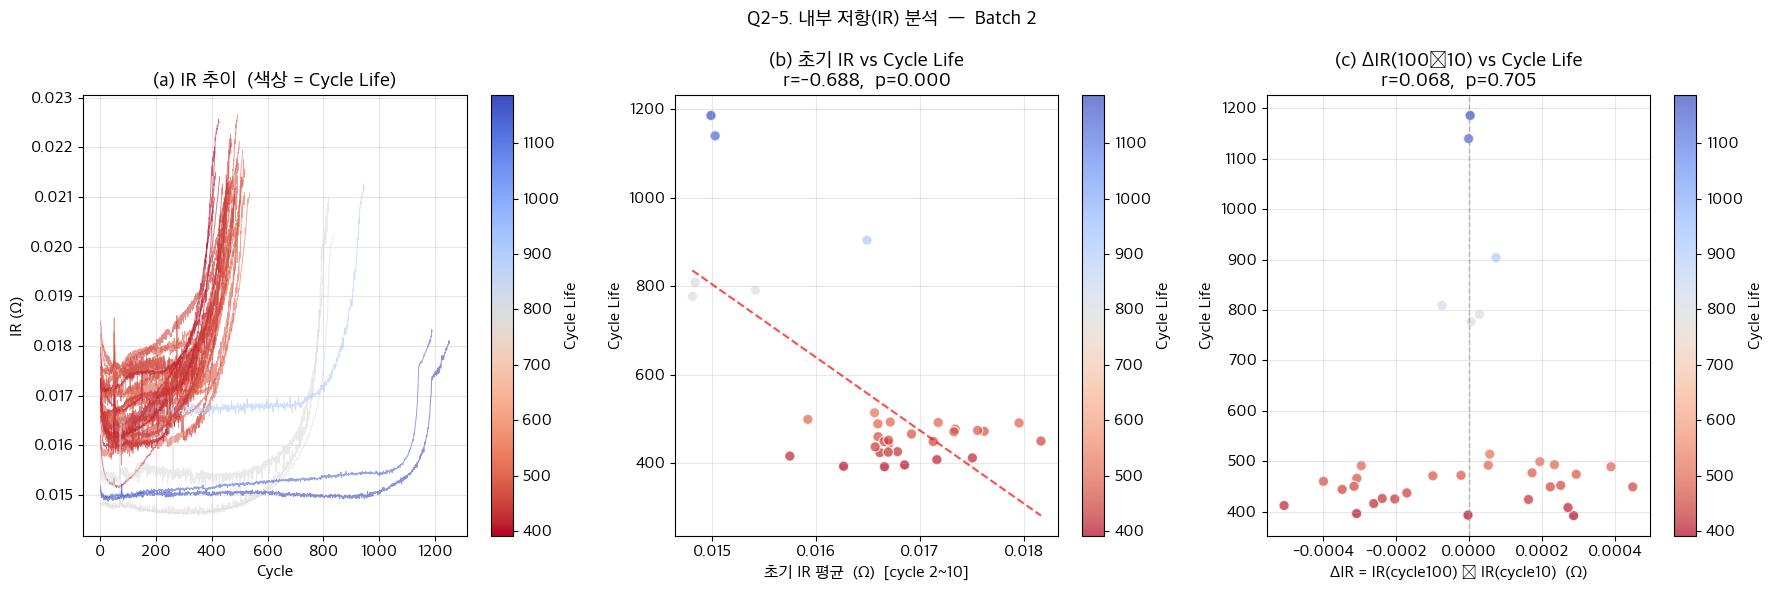


Batch 2 IR 분석:
  초기 IR 범위: 0.0148 ~ 0.0182 Ω
  초기 IR vs CL : r=-0.6881,  p=0.0000
  ΔIR   vs CL : r=0.0684,  p=0.7051


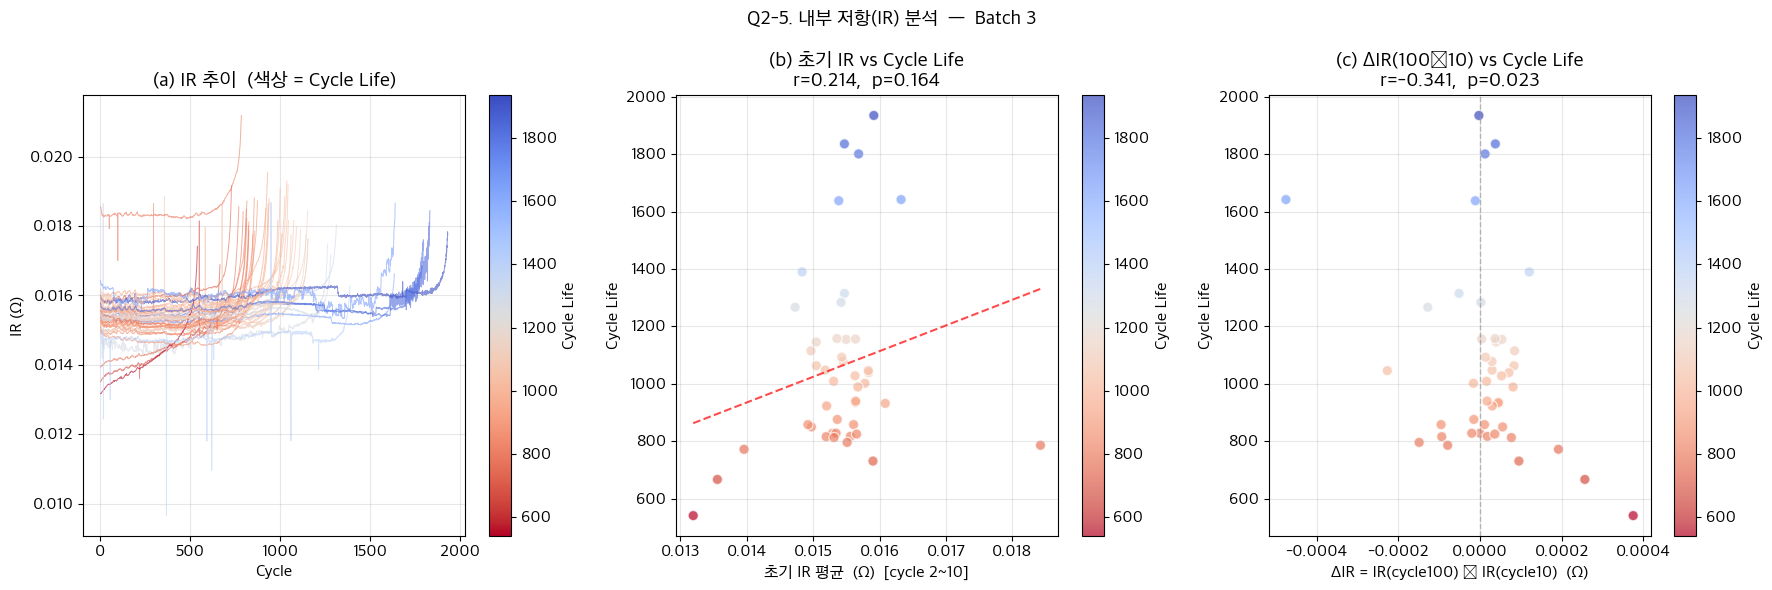


Batch 3 IR 분석:
  초기 IR 범위: 0.0132 ~ 0.0184 Ω
  초기 IR vs CL : r=0.2136,  p=0.1638
  ΔIR   vs CL : r=-0.3415,  p=0.0233


In [12]:
def plot_q2_ir(bname, df_b, save=True):
    """
    (a) 사이클별 IR 추이 (cycle_life 색상)
    (b) 초기 IR vs Cycle Life
    (c) ΔIR (IR100 - IR10) vs Cycle Life
    """
    df_ir  = df_b[df_b['IR'] > 0].copy()
    cl_map = df_ir.drop_duplicates('cell_id').set_index('cell_id')['cycle_life']
    norm   = plt.Normalize(cl_map.min(), cl_map.max())
    cmap   = cm.coolwarm_r

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Q2-5. 내부 저항(IR) 분석  —  {bname}',
                 fontsize=14, fontweight='bold')

    # (a) IR 추이
    ax = axes[0]
    for cid in df_ir['cell_id'].unique():
        sub   = df_ir[df_ir['cell_id'] == cid]
        q05   = sub['IR'].quantile(0.05)
        q95   = sub['IR'].quantile(0.95)
        sub_f = sub[sub['IR'].between(q05 * 0.5, q95 * 2.0)]
        color = cmap(norm(cl_map[cid]))
        ax.plot(sub_f['cycle'], sub_f['IR'], color=color, lw=0.7, alpha=0.6)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Cycle Life')
    ax.set_xlabel('Cycle');  ax.set_ylabel('IR (Ω)')
    ax.set_title('(a) IR 추이  (색상 = Cycle Life)')

    # (b) 초기 IR vs CL
    ax = axes[1]
    early_ir = (df_ir[df_ir['cycle'].between(2, 10)]
                .groupby('cell_id')['IR'].mean()
                .reset_index()
                .rename(columns={'IR':'early_IR'}))
    early_ir['cycle_life'] = early_ir['cell_id'].map(cl_map)
    sc = ax.scatter(early_ir['early_IR'], early_ir['cycle_life'],
                    c=early_ir['cycle_life'], cmap='coolwarm_r',
                    alpha=0.7, s=55, edgecolors='white')
    plt.colorbar(sc, ax=ax, label='Cycle Life')
    if len(early_ir) > 2:
        r, p = stats.pearsonr(early_ir['early_IR'], early_ir['cycle_life'])
        z = np.polyfit(early_ir['early_IR'], early_ir['cycle_life'], 1)
        xf = np.linspace(early_ir['early_IR'].min(),
                         early_ir['early_IR'].max(), 100)
        ax.plot(xf, np.polyval(z, xf), 'r--', lw=1.5, alpha=0.7)
        ax.set_title(f'(b) 초기 IR vs Cycle Life\nr={r:.3f},  p={p:.3f}')
    else:
        ax.set_title('(b) 초기 IR vs Cycle Life')
    ax.set_xlabel('초기 IR 평균  (Ω)  [cycle 2~10]')
    ax.set_ylabel('Cycle Life')

    # (c) ΔIR vs CL
    ax = axes[2]
    ir10  = (df_ir[df_ir['cycle'].between(8,  12)]
             .groupby('cell_id')['IR'].mean().rename('ir10'))
    ir100 = (df_ir[df_ir['cycle'].between(95, 105)]
             .groupby('cell_id')['IR'].mean().rename('ir100'))
    ir_d  = pd.concat([ir10, ir100], axis=1).dropna()
    ir_d['diff']       = ir_d['ir100'] - ir_d['ir10']
    ir_d['cycle_life'] = ir_d.index.map(cl_map)

    sc2 = ax.scatter(ir_d['diff'], ir_d['cycle_life'],
                     c=ir_d['cycle_life'], cmap='coolwarm_r',
                     alpha=0.7, s=55, edgecolors='white')
    plt.colorbar(sc2, ax=ax, label='Cycle Life')
    ax.axvline(0, color='gray', ls='--', lw=1, alpha=0.5)
    if len(ir_d) > 2:
        r2, p2 = stats.pearsonr(ir_d['diff'], ir_d['cycle_life'])
        ax.set_title(f'(c) ΔIR(100−10) vs Cycle Life\nr={r2:.3f},  p={p2:.3f}')
    else:
        ax.set_title('(c) ΔIR vs Cycle Life')
    ax.set_xlabel('ΔIR = IR(cycle100) − IR(cycle10)  (Ω)')
    ax.set_ylabel('Cycle Life')

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q2_IR_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    if len(early_ir) > 2:
        r_e, p_e = stats.pearsonr(early_ir['early_IR'],
                                   early_ir['cycle_life'])
        print(f'\n{bname} IR 분석:')
        print(f'  초기 IR 범위: {early_ir["early_IR"].min():.4f} ~'
              f' {early_ir["early_IR"].max():.4f} Ω')
        print(f'  초기 IR vs CL : r={r_e:.4f},  p={p_e:.4f}')
    if len(ir_d) > 2:
        r_d, p_d = stats.pearsonr(ir_d['diff'], ir_d['cycle_life'])
        print(f'  ΔIR   vs CL : r={r_d:.4f},  p={p_d:.4f}')

for bname in BATCHES:
    plot_q2_ir(bname, batch_dfs[bname])

---
# Q3. ΔQ(V) 곡선

ΔQ 계산 완료: 129셀


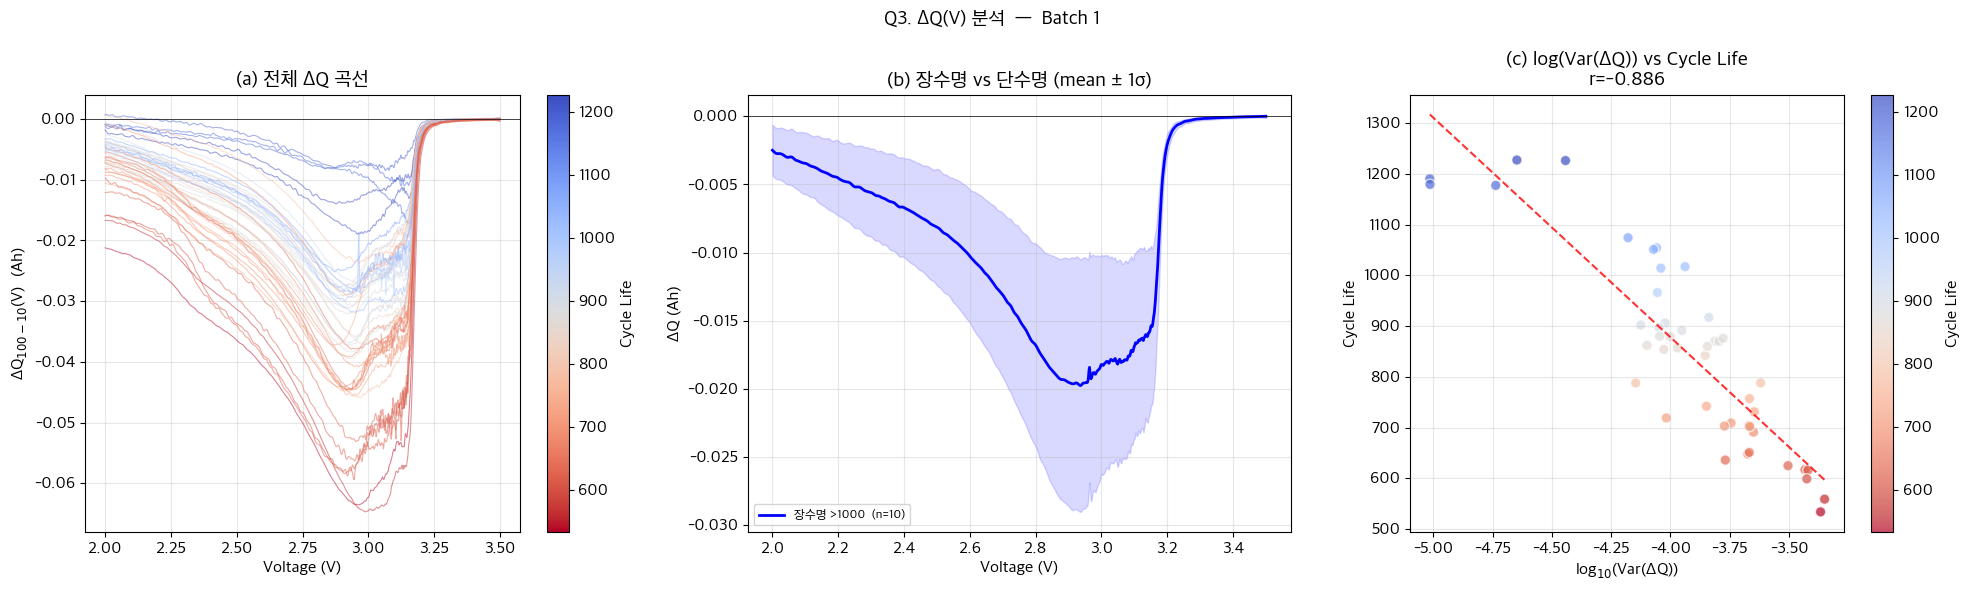

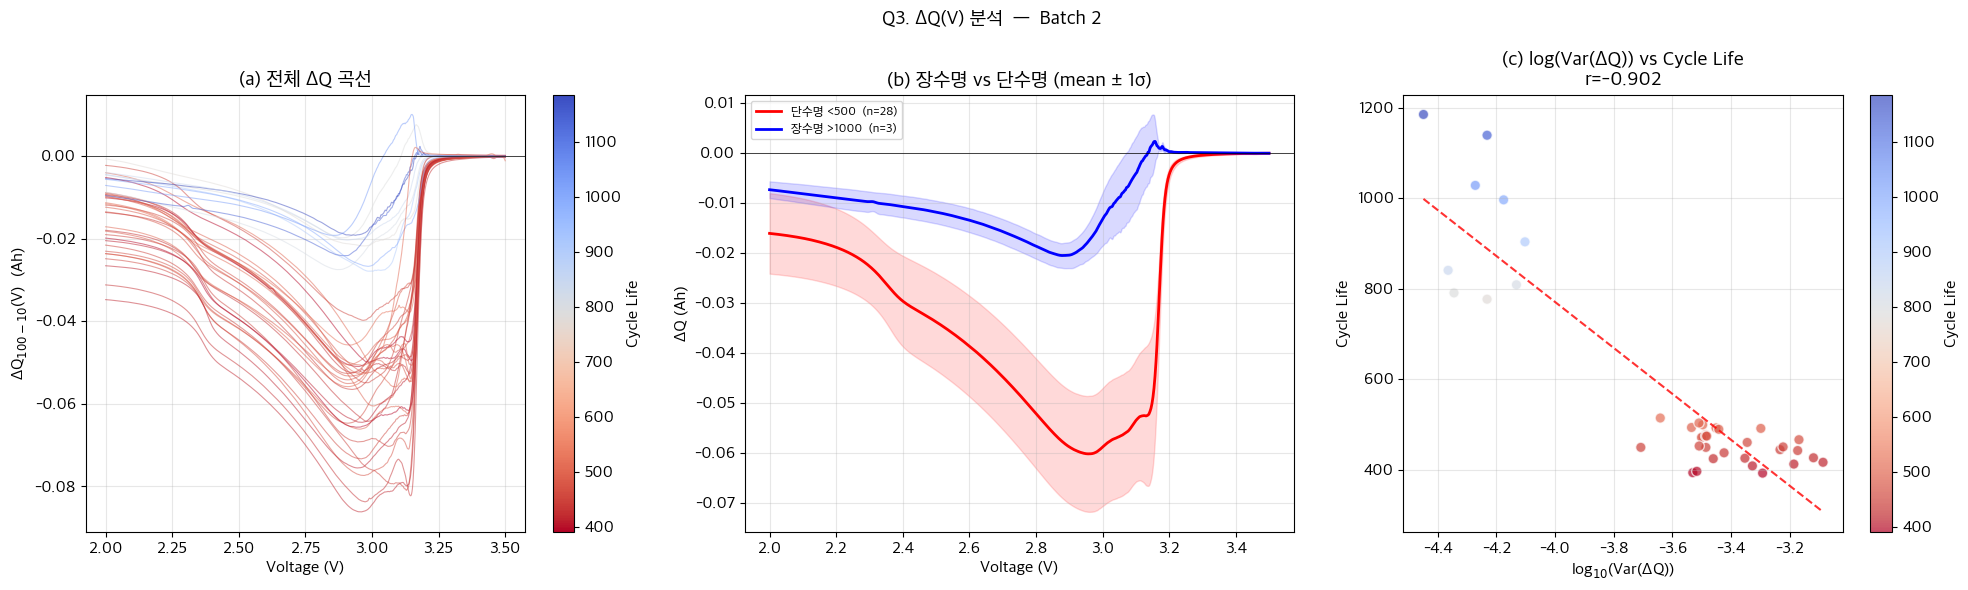

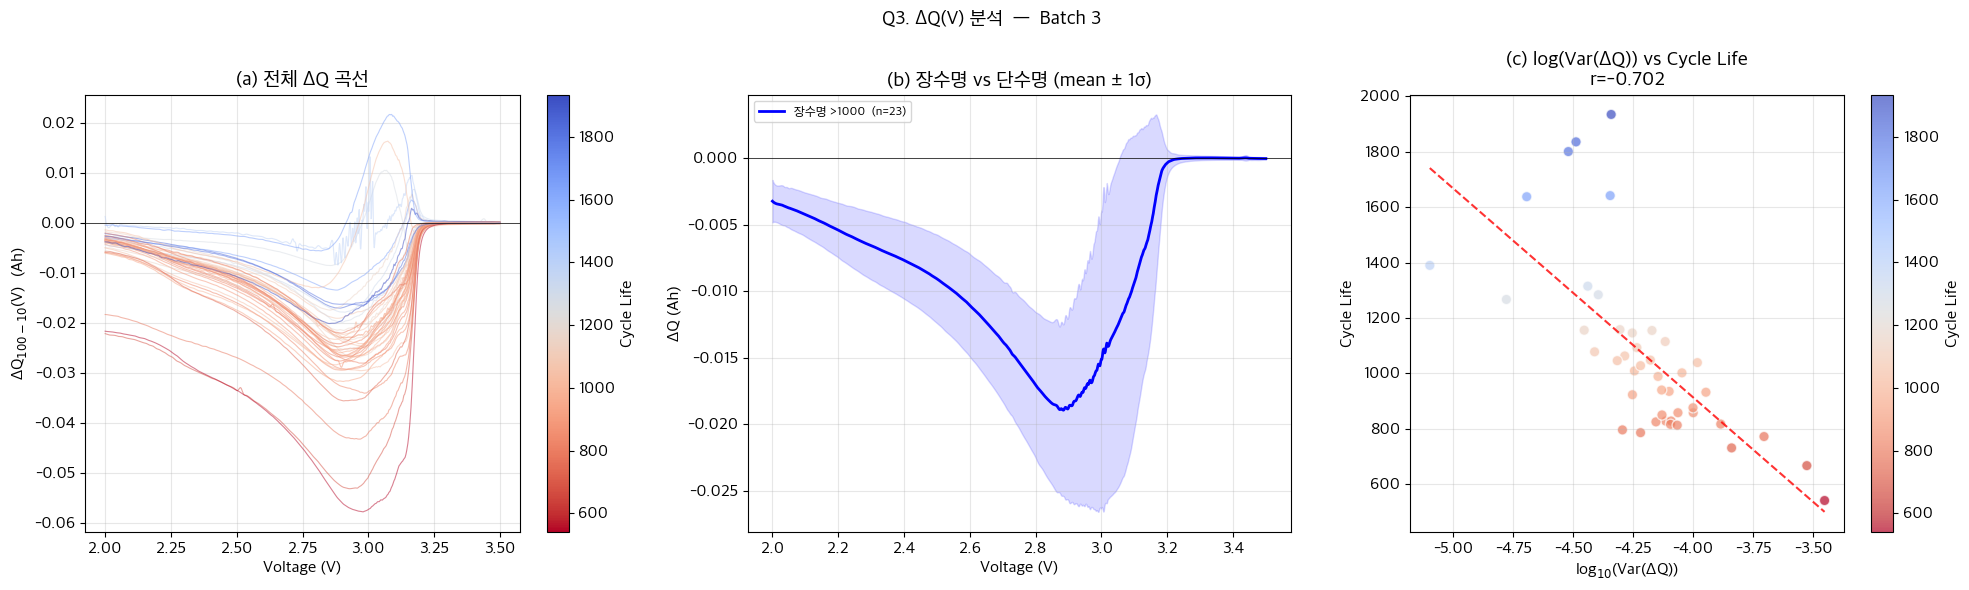


=== ΔQ 피처 vs Cycle Life 상관계수 (전체) ===
  log_dq_variance          : r = -0.8506
  dq_min                   : r = +0.8273
  dq_max_minus_min         : r = -0.7999
  dq_mean                  : r = +0.7974
  dq_abs_mean              : r = -0.7918
  dq_variance              : r = -0.7498
  dq_kurtosis              : r = +0.3647
  dq_skewness              : r = -0.0257


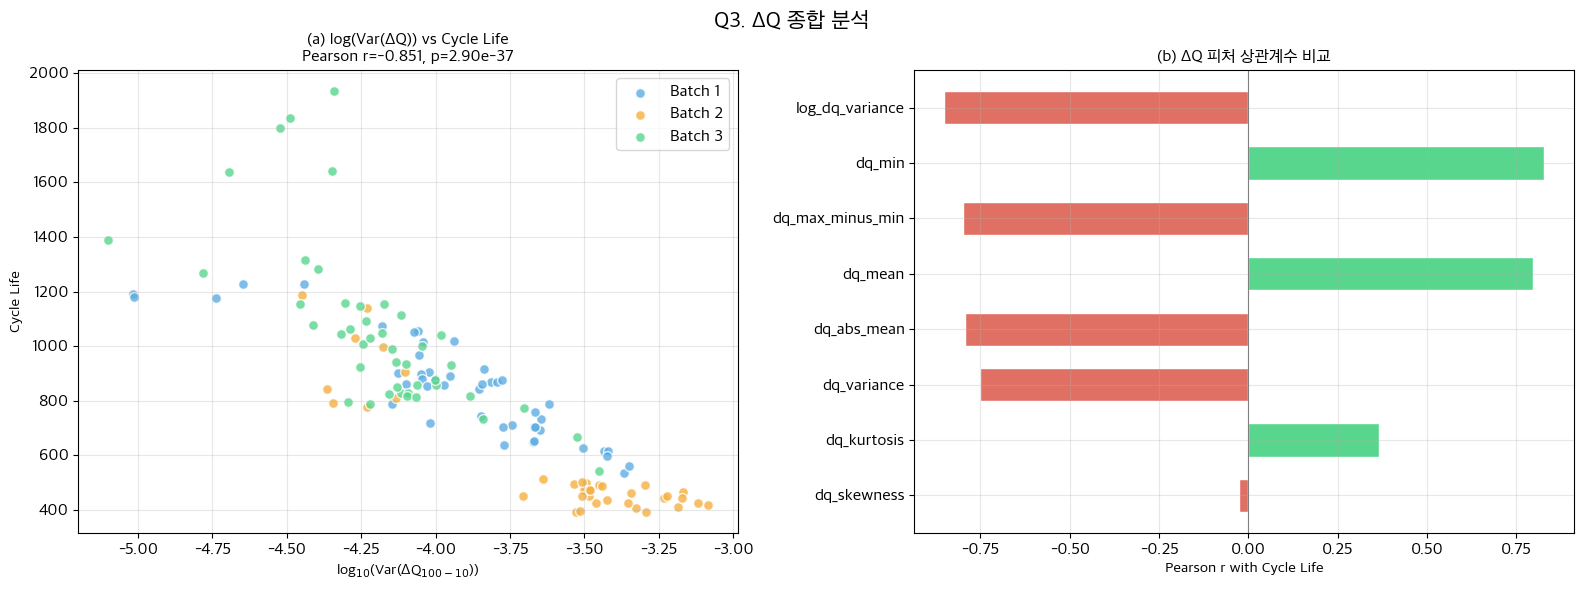

In [13]:
def compute_delta_q(cells, batch_name):
    results = []
    for i, cell in enumerate(cells):
        if cell['Qdlin'].shape[0] < 100:
            continue
        q10, q100 = cell['Qdlin'][9], cell['Qdlin'][99]
        if np.isnan(q10).any() or np.isnan(q100).any():
            continue
        dq = q100 - q10
        results.append({
            'batch':       batch_name,
            'cell_id':     f"{batch_name}_cell{i:02d}",
            'cycle_life':  cell['cycle_life'],
            'policy':      cell['policy'],
            'delta_q':     dq,
            'vdlin':       cell['Vdlin'],
            'dq_variance':      np.var(dq),
            'dq_min':           np.min(dq),
            'dq_mean':          np.mean(dq),
            'dq_skewness':      stats.skew(dq),
            'dq_kurtosis':      stats.kurtosis(dq),
            'dq_max_minus_min': np.max(dq) - np.min(dq),
            'dq_abs_mean':      np.mean(np.abs(dq)),
            'log_dq_variance':  np.log10(np.var(dq) + 1e-10),
        })
    return results

dq_b1 = compute_delta_q(batch1, 'Batch 1')
dq_b2 = compute_delta_q(batch2, 'Batch 2')
dq_b3 = compute_delta_q(batch3, 'Batch 3')
dq_by_batch  = {'Batch 1': dq_b1, 'Batch 2': dq_b2, 'Batch 3': dq_b3}
dq_all_list  = dq_b1 + dq_b2 + dq_b3
dq_features  = pd.DataFrame(
    [{k: v for k, v in d.items() if k not in ['delta_q','vdlin']}
     for d in dq_all_list])
print(f'ΔQ 계산 완료: {len(dq_features)}셀')


def plot_q3(bname, dq_list, save=True):
    if not dq_list:
        return
    vdlin     = dq_list[0]['vdlin']
    cl_values = [d['cycle_life'] for d in dq_list]
    norm      = plt.Normalize(min(cl_values), max(cl_values))
    cmap      = cm.coolwarm_r

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Q3. ΔQ(V) 분석  —  {bname}', fontsize=14, fontweight='bold')

    # (a) 전체 곡선
    ax = axes[0]
    for d in dq_list:
        ax.plot(vdlin, d['delta_q'], color=cmap(norm(d['cycle_life'])),
                alpha=0.5, lw=0.8)
    ax.axhline(0, color='black', lw=0.5)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Cycle Life')
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('ΔQ$_{100-10}$(V)  (Ah)')
    ax.set_title('(a) 전체 ΔQ 곡선')

    # (b) 장수명 vs 단수명
    ax = axes[1]
    short_dq = [d['delta_q'] for d in dq_list if d['cycle_life'] < 500]
    long_dq  = [d['delta_q'] for d in dq_list if d['cycle_life'] > 1000]
    if short_dq:
        ms = np.mean(short_dq, axis=0)
        ax.plot(vdlin, ms, 'r-', lw=2, label=f'단수명 <500  (n={len(short_dq)})')
        ax.fill_between(vdlin, ms - np.std(short_dq, axis=0),
                               ms + np.std(short_dq, axis=0),
                        color='red', alpha=0.15)
    if long_dq:
        ml = np.mean(long_dq, axis=0)
        ax.plot(vdlin, ml, 'b-', lw=2, label=f'장수명 >1000  (n={len(long_dq)})')
        ax.fill_between(vdlin, ml - np.std(long_dq, axis=0),
                               ml + np.std(long_dq, axis=0),
                        color='blue', alpha=0.15)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('ΔQ (Ah)')
    ax.set_title('(b) 장수명 vs 단수명 (mean ± 1σ)')
    ax.legend(fontsize=9)

    # (c) log(Var(ΔQ)) vs CL
    ax = axes[2]
    lv  = np.array([d['log_dq_variance'] for d in dq_list])
    cla = np.array([d['cycle_life']      for d in dq_list])
    sc  = ax.scatter(lv, cla, c=cla, cmap='coolwarm_r',
                     alpha=0.7, s=55, edgecolors='white')
    plt.colorbar(sc, ax=ax, label='Cycle Life')
    if len(lv) > 2:
        r, p = stats.pearsonr(lv, cla)
        z  = np.polyfit(lv, cla, 1)
        xf = np.linspace(lv.min(), lv.max(), 100)
        ax.plot(xf, np.polyval(z, xf), 'r--', lw=1.5, alpha=0.8)
        ax.set_title(f'(c) log(Var(ΔQ)) vs Cycle Life\nr={r:.3f}')
    ax.set_xlabel('log$_{10}$(Var(ΔQ))')
    ax.set_ylabel('Cycle Life')

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q3_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

for bname in BATCHES:
    plot_q3(bname, dq_by_batch[bname])

print('\n=== ΔQ 피처 vs Cycle Life 상관계수 (전체) ===')
feat_cols_dq = [c for c in dq_features.columns
                if c.startswith('dq_') or c.startswith('log_')]
corrs_dq = (dq_features[feat_cols_dq + ['cycle_life']]
            .corr()['cycle_life'].drop('cycle_life')
            .sort_values(key=abs, ascending=False))
for f, v in corrs_dq.items():
    print(f'  {f:25s}: r = {v:+.4f}')
    

# =====================================================================
# Q3 전체 종합 분석 Figure 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q3. ΔQ 종합 분석', fontsize=16, fontweight='bold')

# ---------------------------------------------------------------------
# (a) log(Var(ΔQ)) vs Cycle Life 산점도 (배치별 색상 구분)
# ---------------------------------------------------------------------
ax1 = axes[0]

# 이미지와 유사한 배치별 색상 지정 (파랑, 주황, 초록)
batch_colors = {'Batch 1': '#5DADE2', 'Batch 2': '#F5B041', 'Batch 3': '#58D68D'}

for batch_name in ['Batch 1', 'Batch 2', 'Batch 3']:
    subset = dq_features[dq_features['batch'] == batch_name]
    ax1.scatter(subset['log_dq_variance'], subset['cycle_life'],
                label=batch_name, color=batch_colors.get(batch_name, 'gray'),
                alpha=0.8, edgecolors='white', s=50)

# 전체 데이터를 바탕으로 Pearson 상관계수 및 p-value 계산
r_val, p_val = stats.pearsonr(dq_features['log_dq_variance'], dq_features['cycle_life'])

ax1.set_title(f'(a) log(Var(ΔQ)) vs Cycle Life\nPearson r={r_val:.3f}, p={p_val:.2e}', fontsize=12)
ax1.set_xlabel('log$_{10}$(Var(ΔQ$_{100-10}$))', fontsize=11)
ax1.set_ylabel('Cycle Life', fontsize=11)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)


# ---------------------------------------------------------------------
# (b) ΔQ 피처 상관계수 비교 (가로 막대 그래프)
# ---------------------------------------------------------------------
ax2 = axes[1]

# 이미지에 나타난 Y축 피처 순서 지정 (그래프는 아래에서부터 위로 그려지므로 역순 배치)
feature_order = [
    'dq_skewness',
    'dq_kurtosis',
    'dq_variance',
    'dq_abs_mean',
    'dq_mean',
    'dq_max_minus_min',
    'dq_min',
    'log_dq_variance'
]

# 앞선 코드에서 계산된 corrs_dq에서 해당 피처의 상관계수 값 추출
corr_values = [corrs_dq[feat] for feat in feature_order]

# 양수(초록색 계열), 음수(붉은색 계열)에 따른 색상 리스트 생성
bar_colors = ['#58D68D' if val > 0 else '#E17064' for val in corr_values]

# 수평 막대 그래프 생성
ax2.barh(feature_order, corr_values, color=bar_colors, edgecolor='white', height=0.6)

# 기준이 되는 0점 수직선 추가
ax2.axvline(0, color='gray', lw=0.8)

ax2.set_title('(b) ΔQ 피처 상관계수 비교', fontsize=12)
ax2.set_xlabel('Pearson r with Cycle Life', fontsize=11)
ax2.grid(True, alpha=0.3)

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.subplots_adjust(top=0.88) # 메인 타이틀(suptitle) 공간 확보
plt.savefig('figures/q3_overall_analysis.png', dpi=150, bbox_inches='tight') # 필요시 주석 해제하여 저장
plt.show()

---
# Q4. 충전 조건(C-rate)과 수명

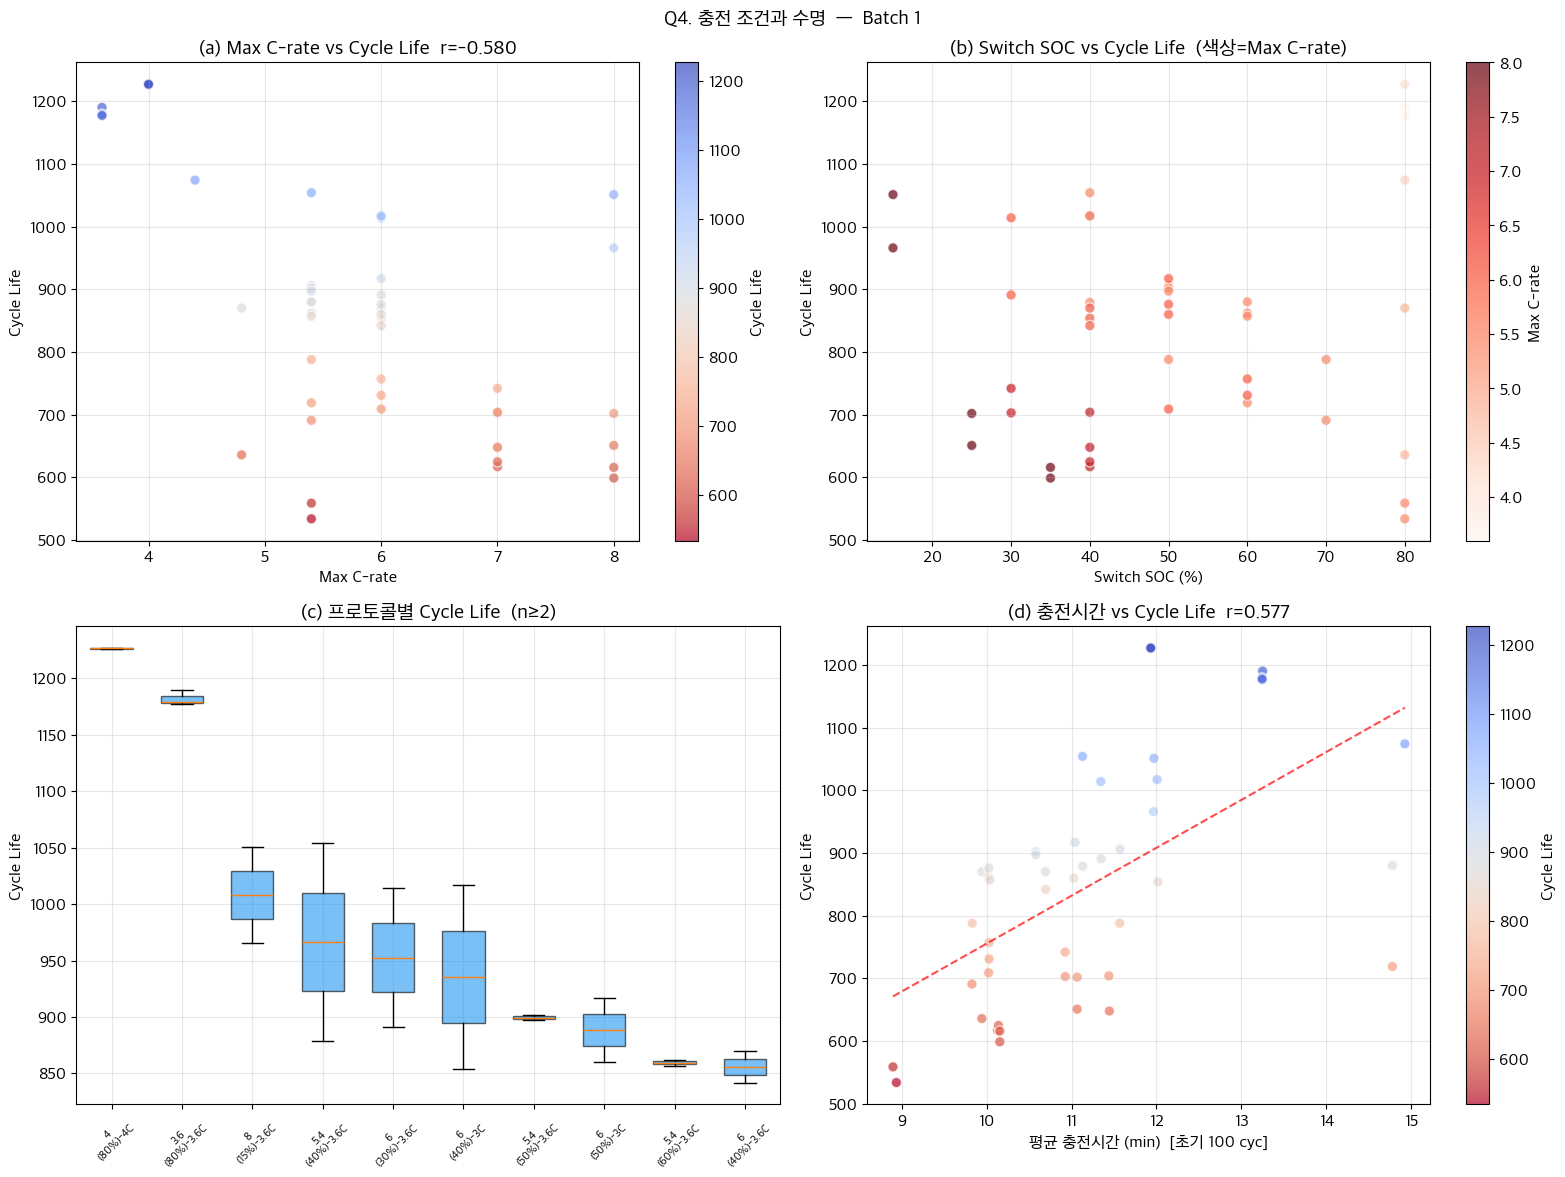

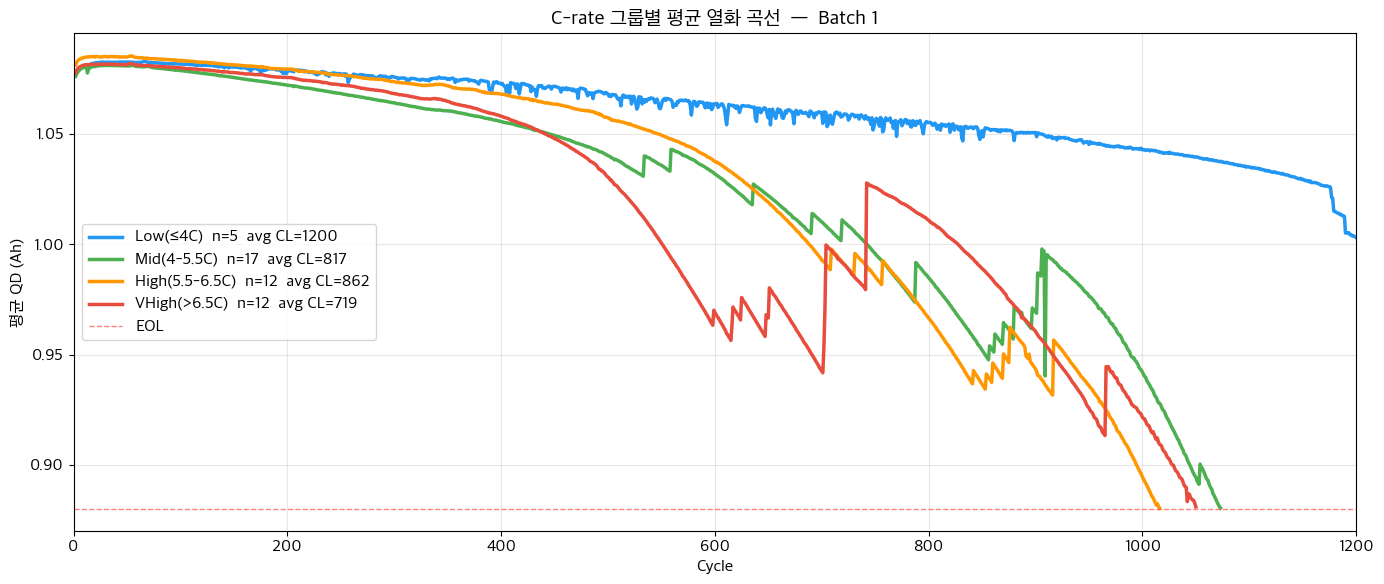

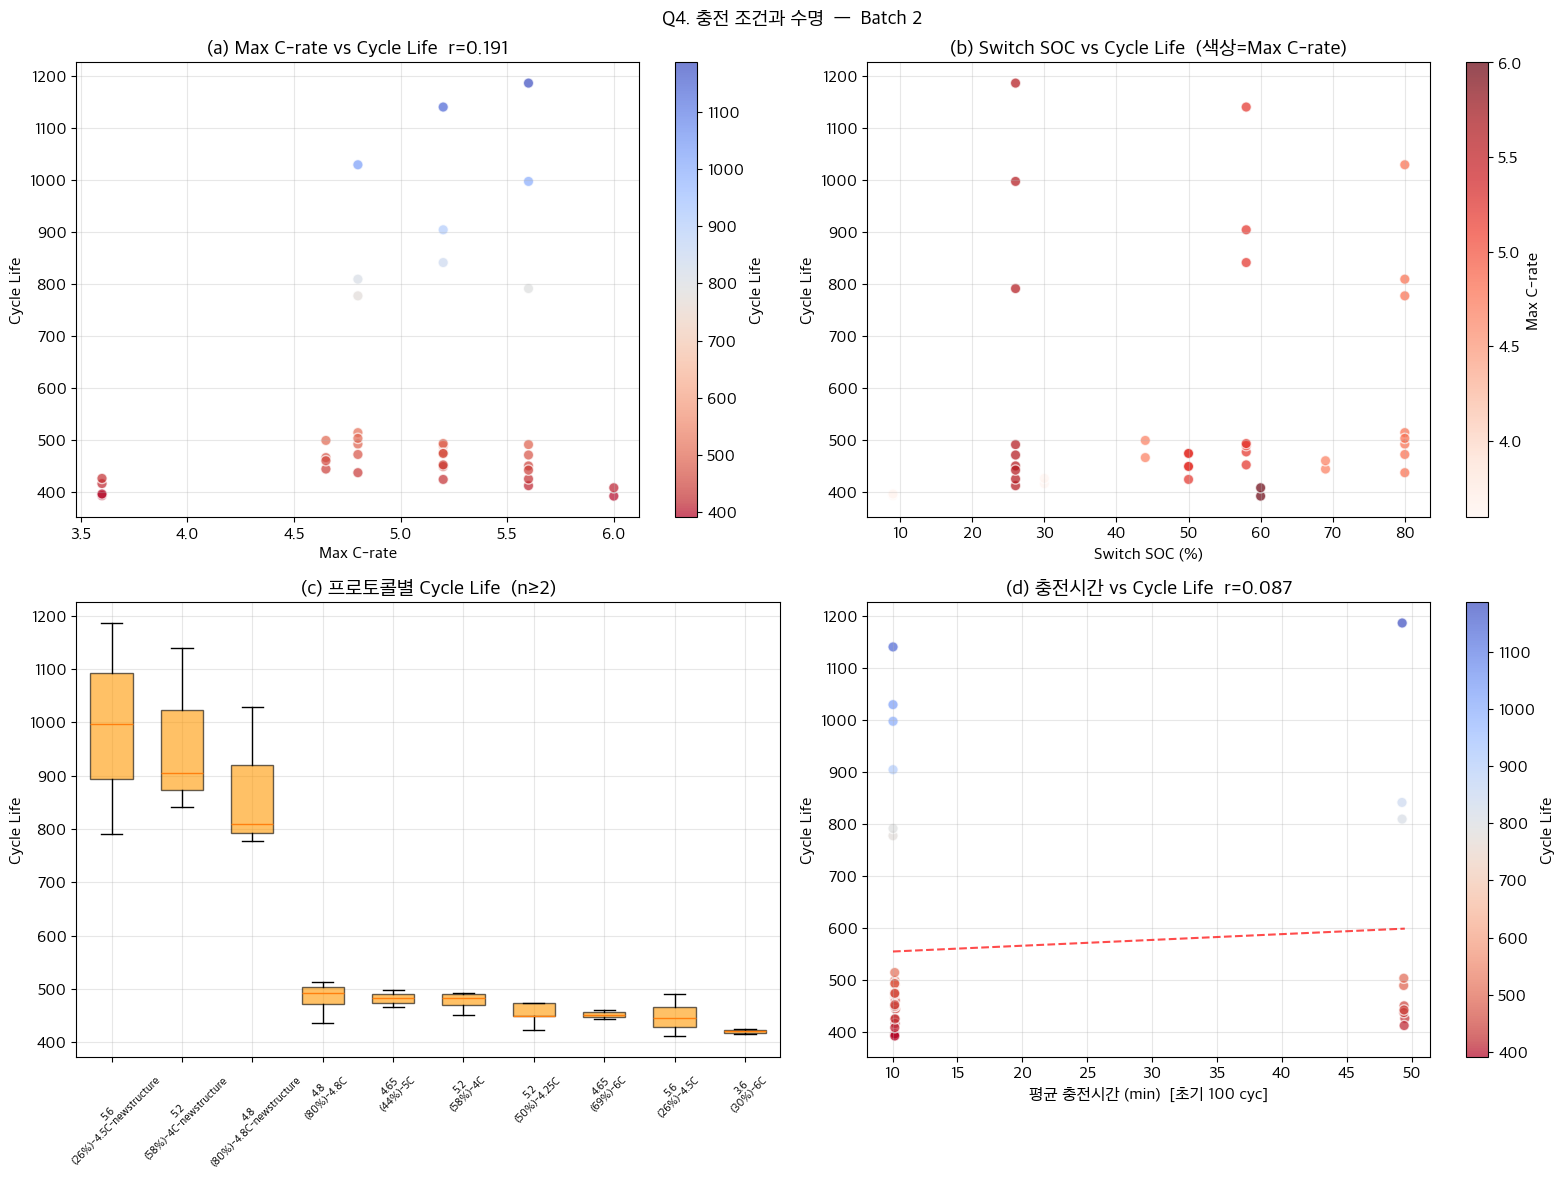

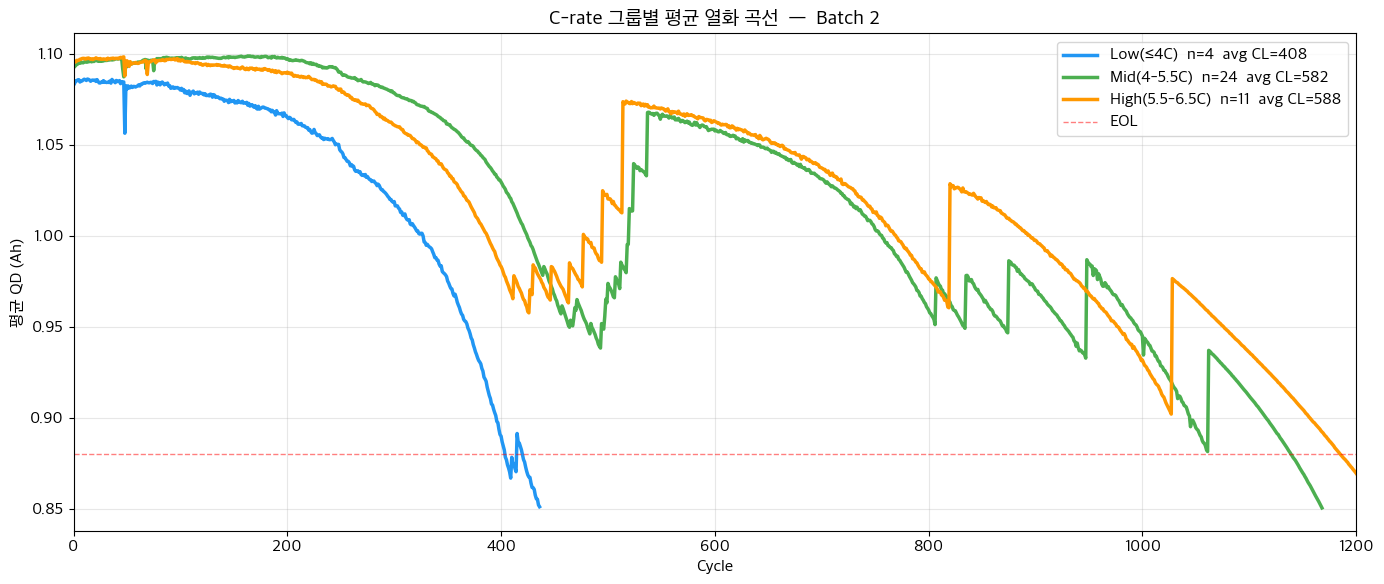

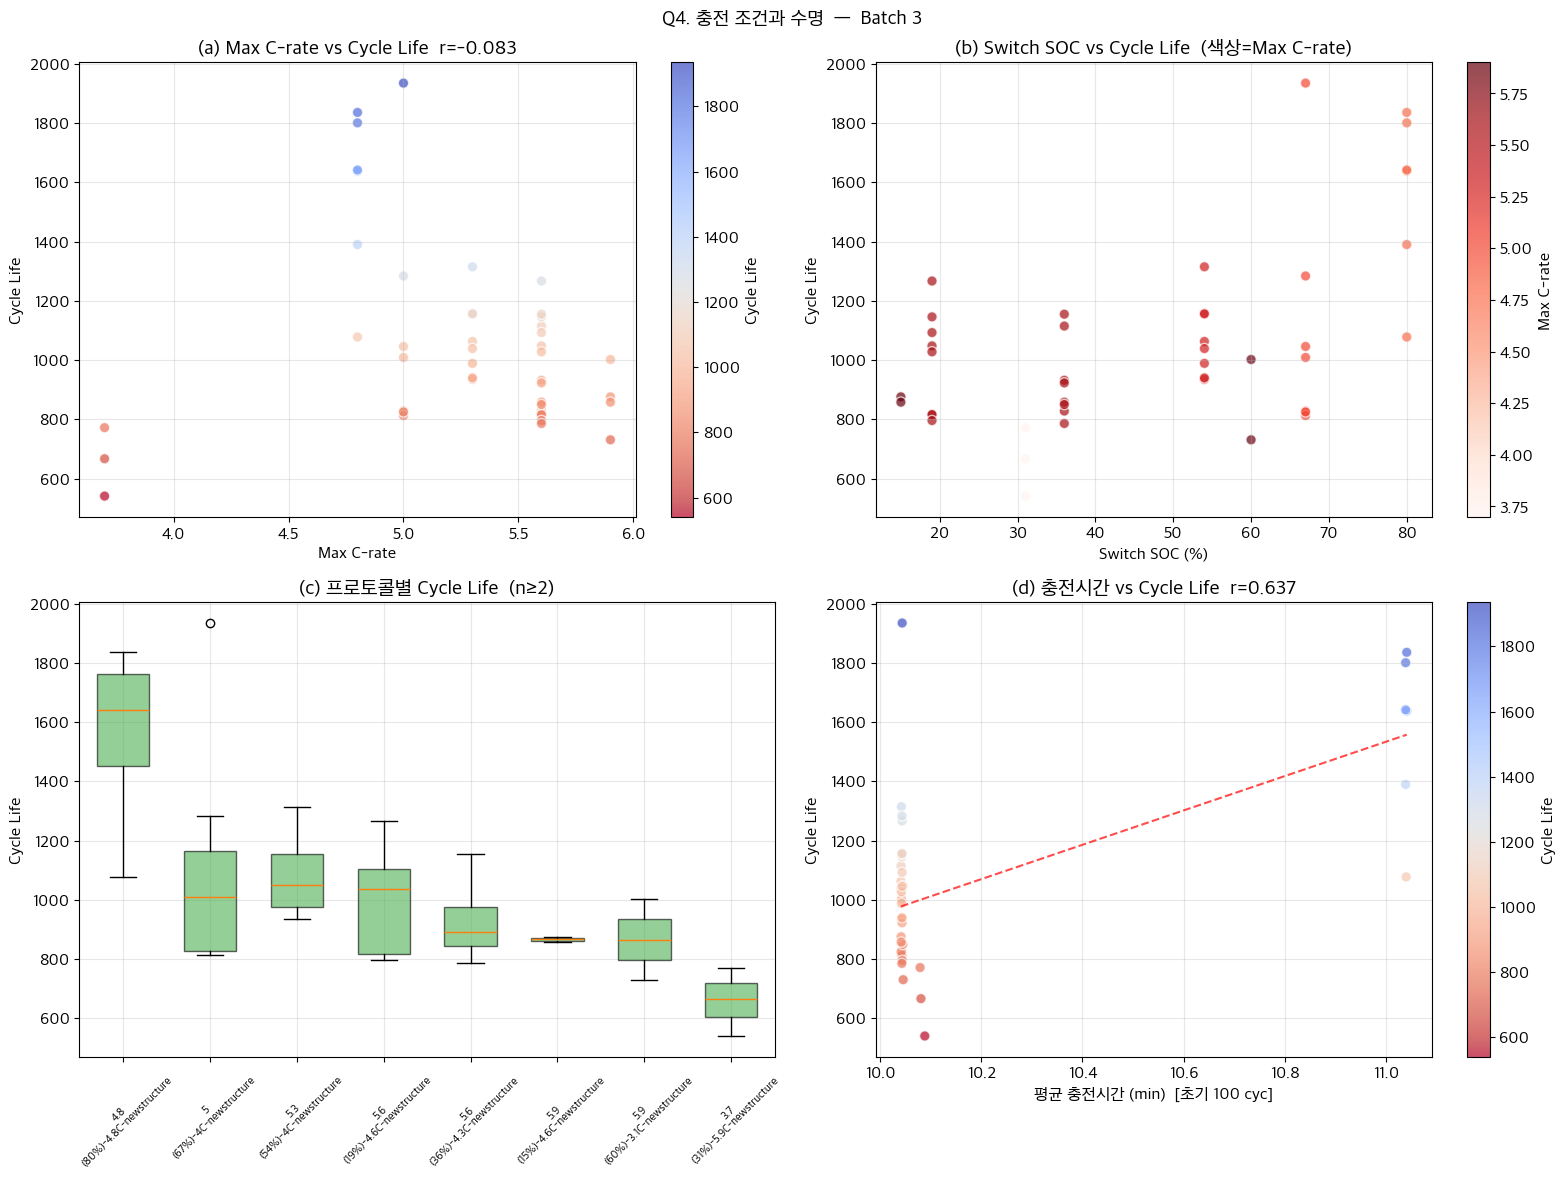

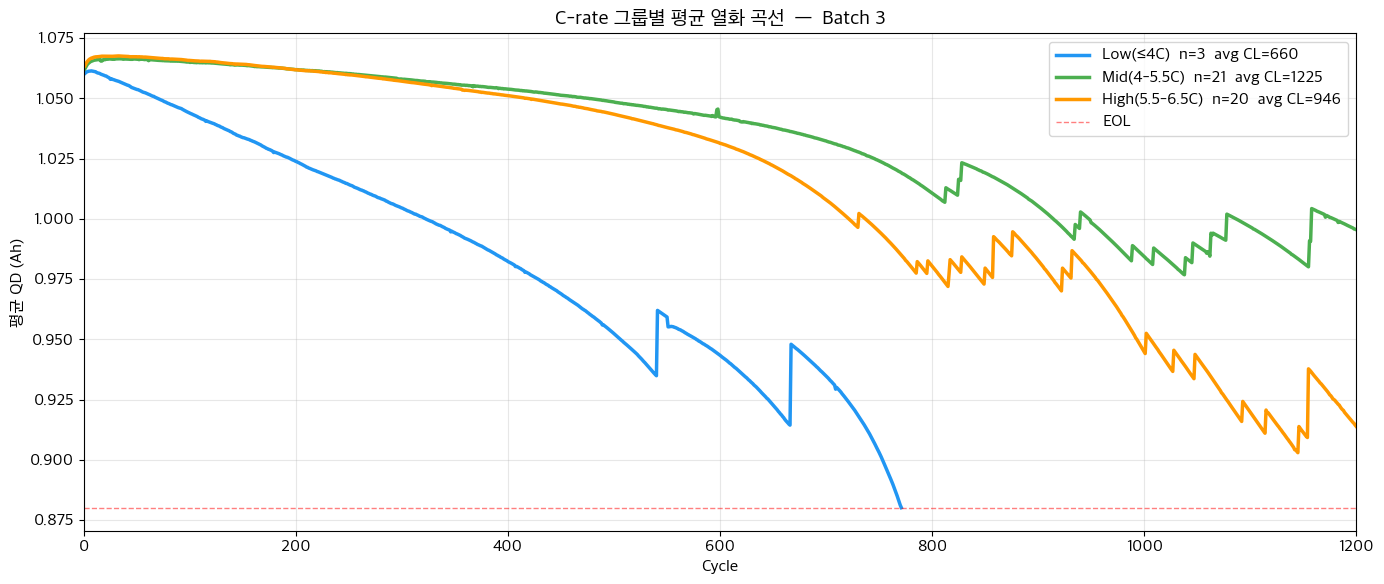

In [14]:
def parse_policy(s):
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', s)
    if m:
        return float(m.group(1)), int(m.group(2)), float(m.group(3))
    return np.nan, np.nan, np.nan

pp = cell_info['policy'].apply(
    lambda x: pd.Series(parse_policy(x),
                        index=['max_crate','switch_pct','second_crate']))
cell_policy = pd.concat([cell_info, pp], axis=1)
cell_policy['crate_group'] = pd.cut(
    cell_policy['max_crate'],
    bins=[0, 4, 5.5, 6.5, 10],
    labels=['Low(≤4C)','Mid(4-5.5C)','High(5.5-6.5C)','VHigh(>6.5C)'])

early_ct = (df_all[df_all['cycle'] <= 100]
            .groupby('cell_id')
            .agg(cycle_life=('cycle_life','first'),
                 batch=('batch','first'),
                 mean_chargetime=('chargetime','mean'))
            .reset_index())

CRATE_COL = {'Low(≤4C)':'#2196F3','Mid(4-5.5C)':'#4CAF50',
             'High(5.5-6.5C)':'#FF9800','VHigh(>6.5C)':'#e74c3c'}


def plot_q4(bname, df_b, cell_policy_all, early_ct_all, save=True):
    cp_b  = cell_policy_all[cell_policy_all['batch'] == bname]
    ct_b  = early_ct_all[early_ct_all['batch'] == bname]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Q4. 충전 조건과 수명  —  {bname}',
                 fontsize=14, fontweight='bold')

    # (a) Max C-rate vs CL
    ax = axes[0, 0]
    cpv = cp_b.dropna(subset=['max_crate'])
    sc  = ax.scatter(cpv['max_crate'], cpv['cycle_life'],
                     c=cpv['cycle_life'], cmap='coolwarm_r',
                     alpha=0.7, s=55, edgecolors='white')
    plt.colorbar(sc, ax=ax, label='Cycle Life')
    if len(cpv) > 2:
        r, _ = stats.pearsonr(cpv['max_crate'], cpv['cycle_life'])
        ax.set_title(f'(a) Max C-rate vs Cycle Life  r={r:.3f}')
    else:
        ax.set_title('(a) Max C-rate vs Cycle Life')
    ax.set_xlabel('Max C-rate');  ax.set_ylabel('Cycle Life')

    # (b) Switch SOC vs CL
    ax = axes[0, 1]
    sc2 = ax.scatter(cpv['switch_pct'], cpv['cycle_life'],
                     c=cpv['max_crate'], cmap='Reds',
                     alpha=0.7, s=55, edgecolors='white')
    plt.colorbar(sc2, ax=ax, label='Max C-rate')
    ax.set_xlabel('Switch SOC (%)')
    ax.set_ylabel('Cycle Life')
    ax.set_title('(b) Switch SOC vs Cycle Life  (색상=Max C-rate)')

    # (c) 프로토콜별 Boxplot
    ax = axes[1, 0]
    top_pol = (cp_b.groupby('policy')['cycle_life']
               .agg(['mean','count'])
               .query('count >= 2')
               .sort_values('mean', ascending=False))
    top_names = top_pol.index[:10]
    if len(top_names):
        data_bp = [cp_b[cp_b['policy'] == p]['cycle_life'].values
                   for p in top_names]
        bp = ax.boxplot(data_bp,
                        labels=[p.replace('C(', '\n(') for p in top_names],
                        patch_artist=True, widths=0.6)
        for patch in bp['boxes']:
            patch.set_facecolor(BATCH_COLORS[bname])
            patch.set_alpha(0.6)
    ax.set_ylabel('Cycle Life')
    ax.set_title('(c) 프로토콜별 Cycle Life  (n≥2)')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # (d) 평균 충전시간 vs CL
    ax = axes[1, 1]
    sc3 = ax.scatter(ct_b['mean_chargetime'], ct_b['cycle_life'],
                     c=ct_b['cycle_life'], cmap='coolwarm_r',
                     alpha=0.7, s=55, edgecolors='white')
    plt.colorbar(sc3, ax=ax, label='Cycle Life')
    if len(ct_b) > 2:
        r3, _ = stats.pearsonr(ct_b['mean_chargetime'], ct_b['cycle_life'])
        z = np.polyfit(ct_b['mean_chargetime'], ct_b['cycle_life'], 1)
        xf = np.linspace(ct_b['mean_chargetime'].min(),
                         ct_b['mean_chargetime'].max(), 100)
        ax.plot(xf, np.polyval(z, xf), 'r--', lw=1.5, alpha=0.7)
        ax.set_title(f'(d) 충전시간 vs Cycle Life  r={r3:.3f}')
    else:
        ax.set_title('(d) 충전시간 vs Cycle Life')
    ax.set_xlabel('평균 충전시간 (min)  [초기 100 cyc]')
    ax.set_ylabel('Cycle Life')

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q4_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    # C-rate 그룹별 평균 열화 곡선
    fig2, ax2 = plt.subplots(figsize=(14, 6))
    for grp in ['Low(≤4C)','Mid(4-5.5C)','High(5.5-6.5C)','VHigh(>6.5C)']:
        gcells = cp_b[cp_b['crate_group'] == grp]['cell_id'].values
        gdf    = df_b[df_b['cell_id'].isin(gcells)]
        if len(gdf) == 0:
            continue
        mq  = gdf.groupby('cycle')['QD'].mean()
        mq  = mq[mq.between(0.85, 1.15)]
        n   = len(gcells)
        avg = cp_b[cp_b['crate_group'] == grp]['cycle_life'].mean()
        ax2.plot(mq.index, mq.values, lw=2.5, color=CRATE_COL[grp],
                 label=f'{grp}  n={n}  avg CL={avg:.0f}')
    ax2.axhline(0.88, color='red', ls='--', lw=1, alpha=0.5, label='EOL')
    ax2.set_xlim(0, 1200)
    ax2.set_xlabel('Cycle');  ax2.set_ylabel('평균 QD (Ah)')
    ax2.set_title(f'C-rate 그룹별 평균 열화 곡선  —  {bname}')
    ax2.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q4_crate_group_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

for bname in BATCHES:
    plot_q4(bname, batch_dfs[bname], cell_policy, early_ct)

---
# Q5. 상관관계 분석

최종 피처 테이블: (129, 21)


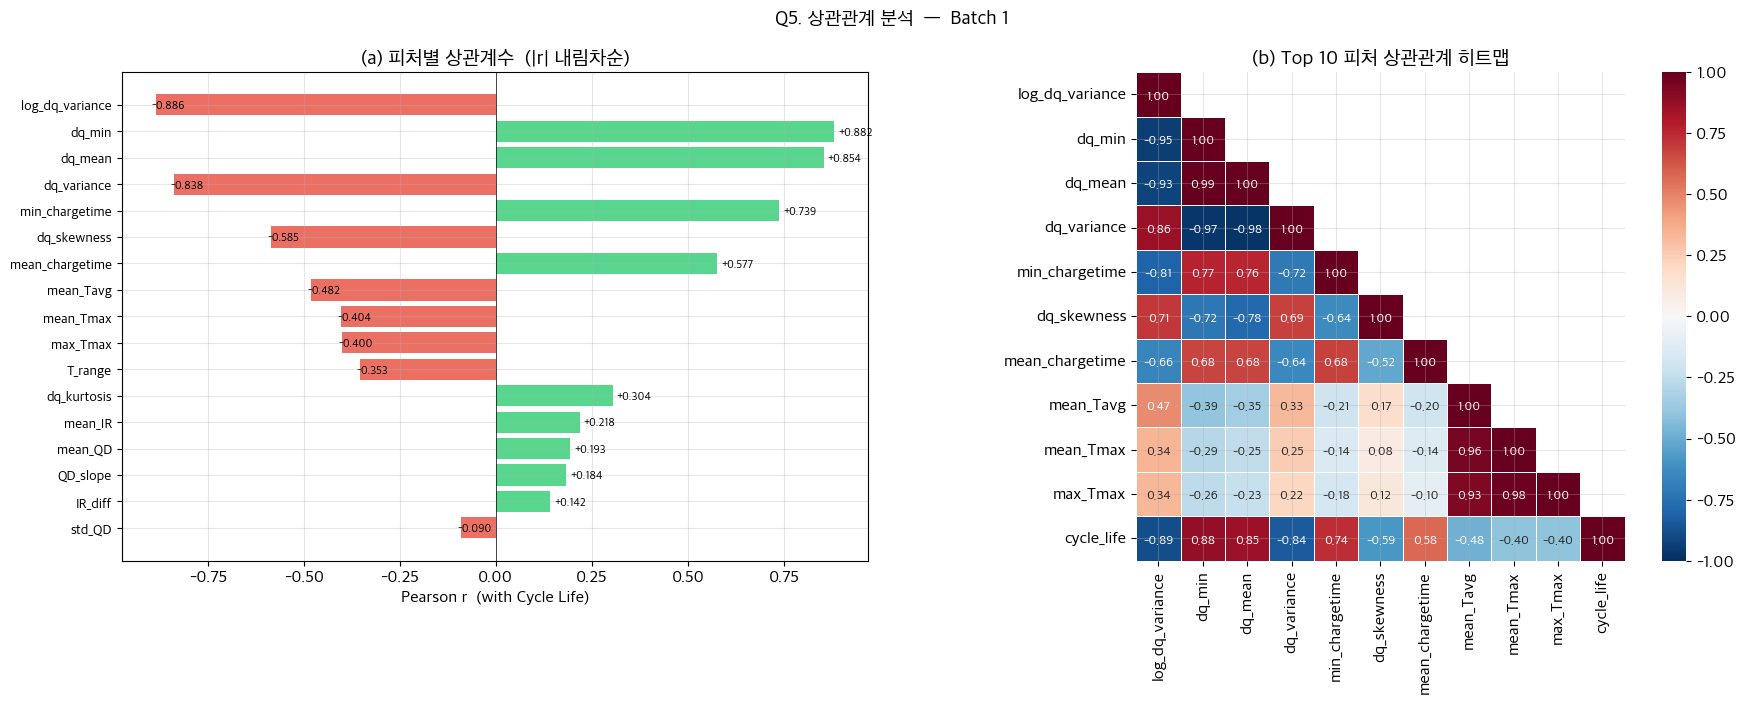


Batch 1 Top 5:
  log_dq_variance          : r = -0.8861
  dq_min                   : r = +0.8816
  dq_mean                  : r = +0.8538
  dq_variance              : r = -0.8378
  min_chargetime           : r = +0.7388


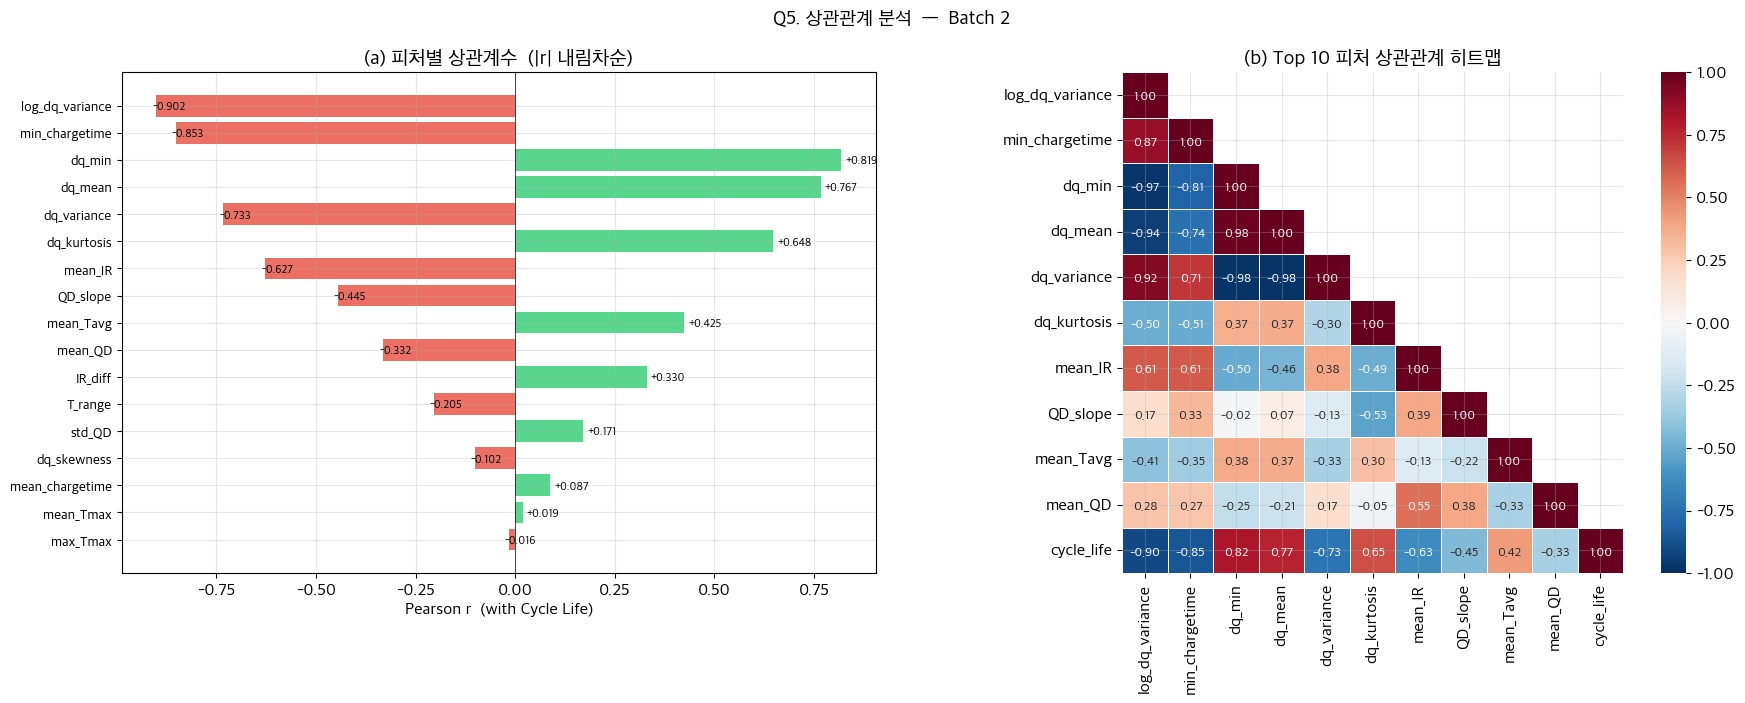


Batch 2 Top 5:
  log_dq_variance          : r = -0.9019
  min_chargetime           : r = -0.8525
  dq_min                   : r = +0.8185
  dq_mean                  : r = +0.7671
  dq_variance              : r = -0.7328


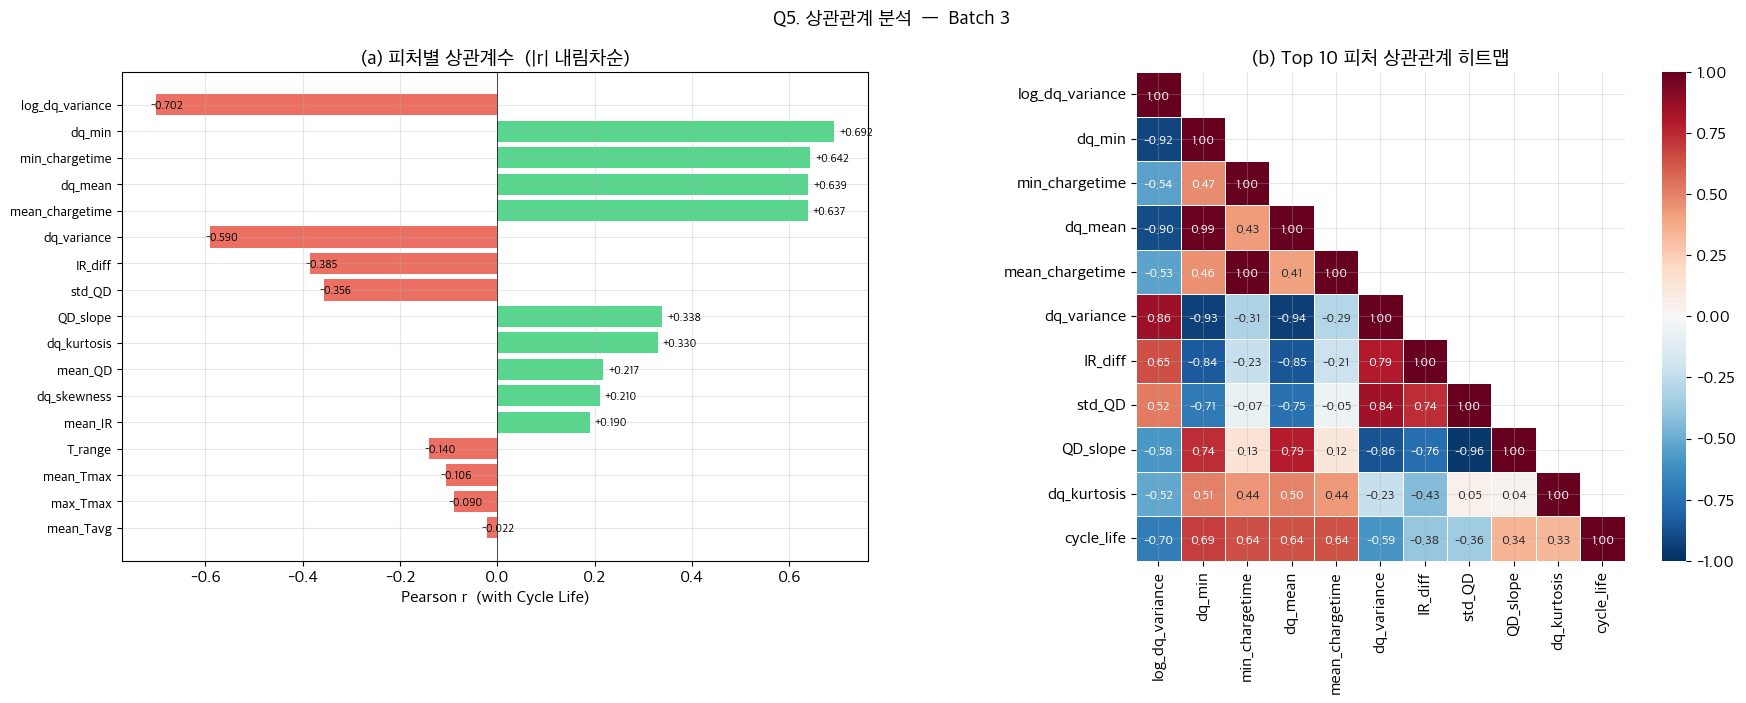


Batch 3 Top 5:
  log_dq_variance          : r = -0.7019
  dq_min                   : r = +0.6921
  min_chargetime           : r = +0.6423
  dq_mean                  : r = +0.6391
  mean_chargetime          : r = +0.6375


In [15]:
def extract_early_features(df_b, cells, batch_name):
    records = []
    for cid in df_b['cell_id'].unique():
        sub = df_b[(df_b['cell_id'] == cid) & (df_b['cycle'] <= 100)]
        if len(sub) < 50:
            continue
        cl  = sub['cycle_life'].iloc[0]
        feat = {
            'batch': batch_name, 'cell_id': cid,
            'cycle_life': cl, 'log_cycle_life': np.log10(cl),
            'mean_QD': sub['QD'].mean(), 'std_QD': sub['QD'].std(),
            'QD_slope': np.nan,
            'mean_IR': sub[sub['IR'] > 0]['IR'].mean(), 'IR_diff': np.nan,
            'mean_Tavg': sub['Tavg'].mean(),
            'mean_Tmax': sub['Tmax'].mean(), 'max_Tmax':  sub['Tmax'].max(),
            'T_range': (sub['Tmax'] - sub['Tmin']).mean(),
            'mean_chargetime': sub[sub['chargetime'] > 0]['chargetime'].mean(),
            'min_chargetime':  sub[sub['chargetime'] > 0]['chargetime'].min(),
        }
        sr = sub[(sub['cycle'] >= 2) & (sub['cycle'] <= 100)]
        if len(sr) > 10:
            feat['QD_slope'] = np.polyfit(sr['cycle'], sr['QD'], 1)[0]
        ir2   = sub[sub['cycle'] == 2  ]['IR']
        ir100 = sub[sub['cycle'] == 100]['IR']
        if len(ir2) and len(ir100) and ir2.values[0] > 0 and ir100.values[0] > 0:
            feat['IR_diff'] = ir100.values[0] - ir2.values[0]
        records.append(feat)
    return pd.DataFrame(records)

feat1 = extract_early_features(df1, batch1, 'Batch 1')
feat2 = extract_early_features(df2, batch2, 'Batch 2')
feat3 = extract_early_features(df3, batch3, 'Batch 3')

dq_sub = dq_features[['cell_id','dq_variance','dq_min','dq_mean',
                       'dq_skewness','dq_kurtosis','log_dq_variance']]
feat_all = (pd.concat([feat1, feat2, feat3], ignore_index=True)
            .merge(dq_sub, on='cell_id', how='left'))
print(f'최종 피처 테이블: {feat_all.shape}')


def plot_q5(bname, feat_all, save=True):
    feat_b = feat_all[feat_all['batch'] == bname].copy()
    fcols  = [c for c in feat_b.columns
              if c not in ['batch','cell_id','cycle_life','log_cycle_life']
              and feat_b[c].notna().sum() > 5]
    corr_cl = (feat_b[fcols + ['cycle_life']].corr()['cycle_life']
               .drop('cycle_life')
               .sort_values(key=abs, ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Q5. 상관관계 분석  —  {bname}',
                 fontsize=14, fontweight='bold')

    # (a) 상관계수 바
    ax = axes[0]
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_cl]
    ax.barh(range(len(corr_cl)), corr_cl.values, color=colors, alpha=0.8)
    ax.set_yticks(range(len(corr_cl)))
    ax.set_yticklabels(corr_cl.index, fontsize=10)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('Pearson r  (with Cycle Life)')
    ax.set_title('(a) 피처별 상관계수  (|r| 내림차순)')
    ax.invert_yaxis()
    for i, (f, v) in enumerate(corr_cl.items()):
        ax.text(v + 0.01*np.sign(v), i, f'{v:+.3f}',
                va='center', fontsize=8)

    # (b) Top 10 히트맵
    ax = axes[1]
    top10 = corr_cl.head(10).index.tolist()
    sub_c = feat_b[top10 + ['cycle_life']].corr()
    mask  = np.triu(np.ones_like(sub_c, dtype=bool), k=1)
    sns.heatmap(sub_c, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
    ax.set_title('(b) Top 10 피처 상관관계 히트맵')

    plt.tight_layout()
    if save:
        plt.savefig(f'figures/q5_{bname.replace(" ","")}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n{bname} Top 5:')
    for f, v in corr_cl.head(5).items():
        print(f'  {f:25s}: r = {v:+.4f}')

for bname in BATCHES:
    plot_q5(bname, feat_all)

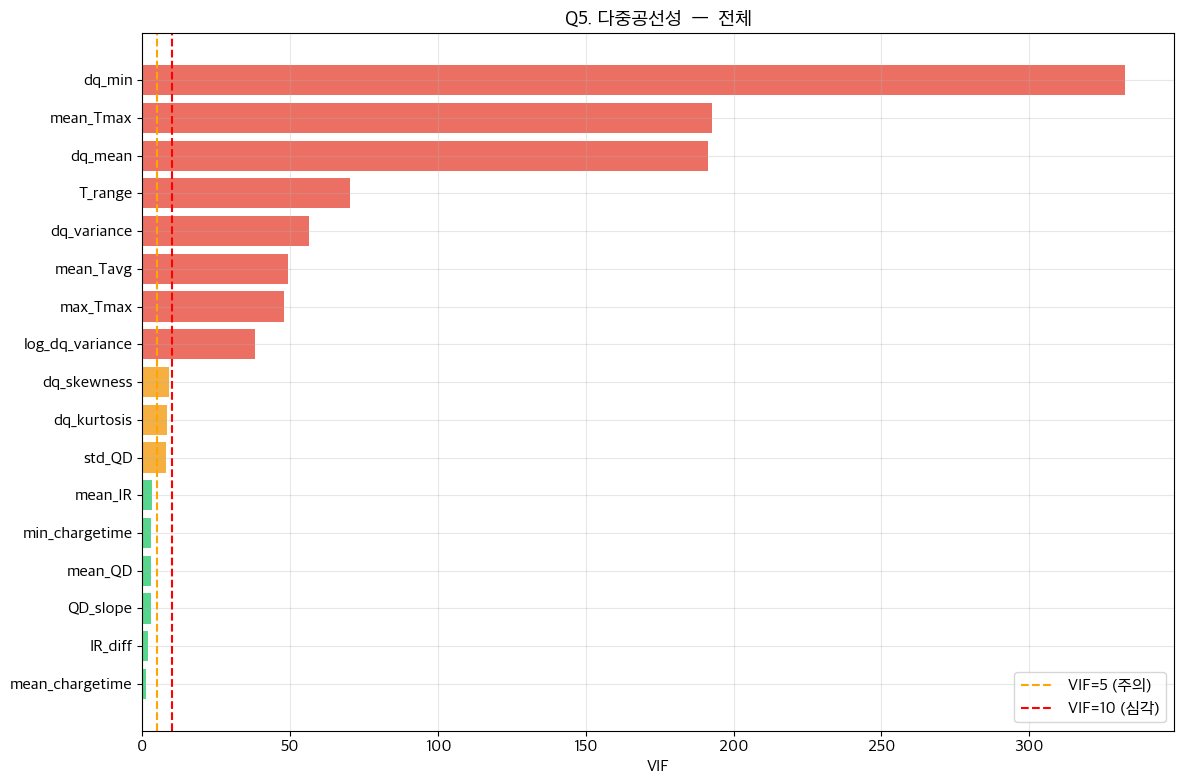


=== VIF > 5 ===
  dq_min                   :    332.4  ⚠ 심각
  mean_Tmax                :    192.6  ⚠ 심각
  dq_mean                  :    191.4  ⚠ 심각
  T_range                  :     70.2  ⚠ 심각
  dq_variance              :     56.4  ⚠ 심각
  mean_Tavg                :     49.3  ⚠ 심각
  max_Tmax                 :     48.0  ⚠ 심각
  log_dq_variance          :     38.2  ⚠ 심각
  dq_skewness              :      8.9  ⚠ 주의
  dq_kurtosis              :      8.5  ⚠ 주의
  std_QD                   :      7.9  ⚠ 주의


In [16]:
# VIF (전체 데이터)
from numpy.linalg import inv

def compute_vif(df, cols):
    X = df[cols].dropna()
    X_std = (X - X.mean()) / X.std()
    try:
        vif = np.diag(inv(X_std.corr().values))
        return pd.Series(vif, index=cols).sort_values(ascending=False)
    except Exception:
        return pd.Series([np.nan]*len(cols), index=cols)

vif_cols = [c for c in feat_all.columns
            if c not in ['batch','cell_id','cycle_life','log_cycle_life']
            and feat_all[c].notna().sum() > len(feat_all) * 0.8]
vif_vals = compute_vif(feat_all, vif_cols)

fig, ax = plt.subplots(figsize=(12, 8))
cv = ['#e74c3c' if v>10 else '#f39c12' if v>5 else '#2ecc71' for v in vif_vals]
ax.barh(range(len(vif_vals)), vif_vals.values, color=cv, alpha=0.8)
ax.set_yticks(range(len(vif_vals)))
ax.set_yticklabels(vif_vals.index)
ax.axvline(5,  color='orange', ls='--', lw=1.5, label='VIF=5 (주의)')
ax.axvline(10, color='red',    ls='--', lw=1.5, label='VIF=10 (심각)')
ax.set_xlabel('VIF');  ax.invert_yaxis()
ax.set_title('Q5. 다중공선성  —  전체', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/q5_vif.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== VIF > 5 ===')
for f, v in vif_vals[vif_vals > 5].items():
    print(f'  {f:25s}: {v:8.1f}  {"⚠ 심각" if v > 10 else "⚠ 주의"}')

---
# Batch 간 비교 요약

In [17]:
print('=' * 65)
print('Batch 간 비교 요약')
print('=' * 65)
for bname in BATCHES:
    sub = cell_info[cell_info['batch'] == bname]
    fs  = feat_all[feat_all['batch'] == bname]
    print(f'\n{bname}')
    print(f'  셀 수      : {len(sub)}')
    print(f'  Cycle Life : {sub["cycle_life"].mean():.0f} ± {sub["cycle_life"].std():.0f}')
    print(f'  정책 수    : {sub["policy"].nunique()}')
    if len(fs):
        print(f'  log(Var(ΔQ)): {fs["log_dq_variance"].mean():.3f} '
              f'± {fs["log_dq_variance"].std():.3f}')
        print(f'  평균 충전시간: {fs["mean_chargetime"].mean():.1f} min')
        print(f'  평균 Tmax  : {fs["mean_Tmax"].mean():.1f} °C')

compare = [('cycle_life', cell_info), ('log_dq_variance', feat_all),
           ('mean_chargetime', feat_all), ('mean_Tmax', feat_all)]
print('\n=== Batch 간 KS-test ===')
for feat, src in compare:
    d = {b: src[src['batch'] == b][feat].dropna() for b in BATCHES}
    ks12 = stats.ks_2samp(d['Batch 1'], d['Batch 2'])
    ks13 = stats.ks_2samp(d['Batch 1'], d['Batch 3'])
    ks23 = stats.ks_2samp(d['Batch 2'], d['Batch 3'])
    print(f'\n{feat}:')
    print(f'  B1 vs B2: KS={ks12.statistic:.3f}, p={ks12.pvalue:.4f}')
    print(f'  B1 vs B3: KS={ks13.statistic:.3f}, p={ks13.pvalue:.4f}')
    print(f'  B2 vs B3: KS={ks23.statistic:.3f}, p={ks23.pvalue:.4f}')

Batch 간 비교 요약

Batch 1
  셀 수      : 46
  Cycle Life : 845 ± 185
  정책 수    : 23
  log(Var(ΔQ)): -3.923 ± 0.378
  평균 충전시간: 11.3 min
  평균 Tmax  : 35.5 °C

Batch 2
  셀 수      : 39
  Cycle Life : 566 ± 222
  정책 수    : 12
  log(Var(ΔQ)): -3.596 ± 0.394
  평균 충전시간: 20.2 min
  평균 Tmax  : 36.2 °C

Batch 3
  셀 수      : 44
  Cycle Life : 1060 ± 314
  정책 수    : 8
  log(Var(ΔQ)): -4.194 ± 0.292
  평균 충전시간: 10.2 min
  평균 Tmax  : 36.9 °C

=== Batch 간 KS-test ===

cycle_life:
  B1 vs B2: KS=0.769, p=0.0000
  B1 vs B3: KS=0.397, p=0.0011
  B2 vs B3: KS=0.769, p=0.0000

log_dq_variance:
  B1 vs B2: KS=0.591, p=0.0000
  B1 vs B3: KS=0.555, p=0.0000
  B2 vs B3: KS=0.701, p=0.0000

mean_chargetime:
  B1 vs B2: KS=0.461, p=0.0001
  B1 vs B3: KS=0.733, p=0.0000
  B2 vs B3: KS=0.710, p=0.0000

mean_Tmax:
  B1 vs B2: KS=0.266, p=0.0801
  B1 vs B3: KS=0.456, p=0.0001
  B2 vs B3: KS=0.224, p=0.2070


In [18]:
feat_all.to_csv('feat_all.csv', index=False)